# 🚗 Vehicle Loan Default — EDA
**Framework:** 5 Business Themes × Domain-First Questions  
**Data:** `../data/train.csv`  (233,154 สัญญา)

## ⚙️ Setup

In [75]:
import warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

DATA_PATH = "../data/train.csv"
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.upper()
'''
# ── parse age-string columns (e.g. "2yrs 3mon") → total months
def parse_months(s):
    if pd.isna(s): return np.nan
    y = re.search(r"(\d+)yrs", str(s))
    m = re.search(r"(\d+)mon", str(s))
    return int(y.group(1))*12 + int(m.group(1)) if y else np.nan

df["AVERAGE_ACCT_AGE_MON"]    = df["AVERAGE_ACCT_AGE"].apply(parse_months)
df["CREDIT_HISTORY_LEN_MON"]  = df["CREDIT_HISTORY_LENGTH"].apply(parse_months)

# ── compute age
df["DATE_OF_BIRTH"]  = pd.to_datetime(df["DATE_OF_BIRTH"],  dayfirst=True, errors="coerce")
df["DISBURSAL_DATE"] = pd.to_datetime(df["DISBURSAL_DATE"], dayfirst=True, errors="coerce")
df["AGE_AT_DISBURSAL"] = (df["DISBURSAL_DATE"] - df["DATE_OF_BIRTH"]).dt.days // 365
'''
print(f"Shape: {df.shape}")
print(f"Default rate: {df['LOAN_DEFAULT'].mean():.2%}")
df.head(2)

Shape: (233154, 41)
Default rate: 21.71%


,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,...,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
0,420825,50578,58400,89.55,67,22807,45,1441,01-01-1984,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,537409,47145,65550,73.23,67,22807,45,1502,31-07-1985,Self employed,...,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1


## 🔍Data Overview

In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 41 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   UNIQUEID                             233154 non-null  int64  
 1   DISBURSED_AMOUNT                     233154 non-null  int64  
 2   ASSET_COST                           233154 non-null  int64  
 3   LTV                                  233154 non-null  float64
 4   BRANCH_ID                            233154 non-null  int64  
 5   SUPPLIER_ID                          233154 non-null  int64  
 6   MANUFACTURER_ID                      233154 non-null  int64  
 7   CURRENT_PINCODE_ID                   233154 non-null  int64  
 8   DATE_OF_BIRTH                        233154 non-null  str    
 9   EMPLOYMENT_TYPE                      225493 non-null  str    
 10  DISBURSAL_DATE                       233154 non-null  str    
 11  STATE_ID                

In [77]:
df.describe()

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,STATE_ID,EMPLOYEE_CODE_ID,...,SEC_OVERDUE_ACCTS,SEC_CURRENT_BALANCE,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,NO_OF_INQUIRIES,LOAN_DEFAULT
count,233154.000000,233154.000000,2.331540e+05,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,...,233154.000000,2.331540e+05,2.331540e+05,2.331540e+05,2.331540e+05,2.331540e+05,233154.000000,233154.000000,233154.000000,233154.000000
mean,535917.573376,54356.993528,7.586507e+04,74.746530,72.936094,19638.635035,69.028054,3396.880247,7.262243,1549.477148,...,0.007244,5.427793e+03,7.295923e+03,7.179998e+03,1.310548e+04,3.232684e+02,0.381833,0.097481,0.206615,0.217071
std,68315.693711,12971.314171,1.894478e+04,11.456636,69.834995,3491.949566,22.141304,2238.147502,4.482230,975.261278,...,0.111079,1.702370e+05,1.831560e+05,1.825925e+05,1.513679e+05,1.555369e+04,0.955107,0.384439,0.706498,0.412252
min,417428.000000,13320.000000,3.700000e+04,10.030000,1.000000,10524.000000,45.000000,1.000000,1.000000,1.000000,...,0.000000,-5.746470e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,476786.250000,47145.000000,6.571700e+04,68.880000,14.000000,16535.000000,48.000000,1511.000000,4.000000,713.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
50%,535978.500000,53803.000000,7.094600e+04,76.800000,61.000000,20333.000000,86.000000,2970.000000,6.000000,1451.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
75%,595039.750000,60413.000000,7.920175e+04,83.670000,130.000000,23000.000000,86.000000,5677.000000,10.000000,2362.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.999000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000
max,671084.000000,990572.000000,1.628992e+06,95.000000,261.000000,24803.000000,156.000000,7345.000000,22.000000,3795.000000,...,8.000000,3.603285e+07,3.000000e+07,3.000000e+07,2.564281e+07,4.170901e+06,35.000000,20.000000,36.000000,1.000000


In [20]:
# ============================================================
# 1. Shape & Target
# ============================================================
print(f"Shape     : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target    : LOAN_DEFAULT  →  default rate = {df['LOAN_DEFAULT'].mean():.2%}")
df.head(3)


Shape     : 233,154 rows × 56 columns
Target    : LOAN_DEFAULT  →  default rate = 21.71%


,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,...,COST_BIN,SCORE_BAND,HAS_SEC_LOAN,DISBURSAL_YEAR,DISBURSAL_MONTH,AGE_BIN,LTV_HIGH,HAS_OVERDUE,LOW_SCORE,DOC_COUNT
0,420825,50578,58400,89.55,67,22807,45,1441,1984-01-01,Salaried,...,Q1 (Cheap),NaN,0,2018,2018-08,30-35,1,0,1,1
1,537409,47145,65550,73.23,67,22807,45,1502,1985-07-31,Self employed,...,Q1 (Cheap),500-600,0,2018,2018-09,30-35,0,1,1,1
2,417566,53278,61360,89.63,67,22807,45,1497,1985-08-24,Self employed,...,Q1 (Cheap),NaN,0,2018,2018-08,30-35,1,0,1,1


In [21]:
# ============================================================
# 2. Column Metadata
# ============================================================
meta = pd.DataFrame({
    "dtype"    : df.dtypes,
    "non_null" : df.notnull().sum(),
    "null"     : df.isnull().sum(),
    "null_%"   : (df.isnull().mean() * 100).round(2),
    "nunique"  : df.nunique(),
    "sample"   : df.apply(lambda c: c.dropna().iloc[0] if c.notna().any() else np.nan),
})
print("Column Metadata:")
display(meta)


Column Metadata:


,dtype,non_null,null,null_%,nunique,sample
UNIQUEID,int64,233154,0,0.00,233154,420825
DISBURSED_AMOUNT,int64,233154,0,0.00,24565,50578
ASSET_COST,int64,233154,0,0.00,46252,58400
LTV,float64,233154,0,0.00,6579,89.55
BRANCH_ID,int64,233154,0,0.00,82,67
SUPPLIER_ID,int64,233154,0,0.00,2953,22807
MANUFACTURER_ID,int64,233154,0,0.00,11,45
CURRENT_PINCODE_ID,int64,233154,0,0.00,6698,1441
DATE_OF_BIRTH,datetime64[us],233154,0,0.00,15433,1984-01-01 00:00:00
EMPLOYMENT_TYPE,str,225493,7661,3.29,2,Salaried


In [22]:
# ============================================================
# 3. Numeric Summary (key stats)
# ============================================================
num_cols = df.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c not in ("UNIQUEID", "LOAN_DEFAULT")]

stats = df[num_cols].describe(percentiles=[.25, .5, .75, .95]).T
stats["skew"] = df[num_cols].skew().round(2)
stats["kurt"] = df[num_cols].kurt().round(2)
print("Numeric Summary (excl. ID & target):")
display(stats.style.background_gradient(subset=["skew"], cmap="RdYlGn_r"))


Numeric Summary (excl. ID & target):


,count,mean,std,min,25%,50%,75%,95%,max,skew,kurt
DISBURSED_AMOUNT,233154.000000,54356.993528,12971.314171,13320.000000,47145.000000,53803.000000,60413.000000,74122.350000,990572.000000,4.490000,249.990000
ASSET_COST,233154.000000,75865.068144,18944.781289,37000.000000,65717.000000,70946.000000,79201.750000,109680.000000,1628992.000000,6.130000,291.490000
LTV,233154.000000,74.746530,11.456636,10.030000,68.880000,76.800000,83.670000,89.380000,95.000000,-1.080000,1.290000
BRANCH_ID,233154.000000,72.936094,69.834995,1.000000,14.000000,61.000000,130.000000,249.000000,261.000000,1.030000,0.300000
SUPPLIER_ID,233154.000000,19638.635035,3491.949566,10524.000000,16535.000000,20333.000000,23000.000000,24122.000000,24803.000000,-0.170000,-1.480000
MANUFACTURER_ID,233154.000000,69.028054,22.141304,45.000000,48.000000,86.000000,86.000000,86.000000,156.000000,0.390000,-0.720000
CURRENT_PINCODE_ID,233154.000000,3396.880247,2238.147502,1.000000,1511.000000,2970.000000,5677.000000,6942.000000,7345.000000,0.280000,-1.290000
STATE_ID,233154.000000,7.262243,4.482230,1.000000,4.000000,6.000000,10.000000,16.000000,22.000000,0.820000,-0.330000
EMPLOYEE_CODE_ID,233154.000000,1549.477148,975.261278,1.000000,713.000000,1451.000000,2362.000000,3186.000000,3795.000000,0.240000,-1.050000
MOBILENO_AVL_FLAG,233154.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000


Missing Values:


,missing_count,missing_%
SCORE_BAND,116950,50.16
EMPLOYMENT_TYPE,7661,3.29


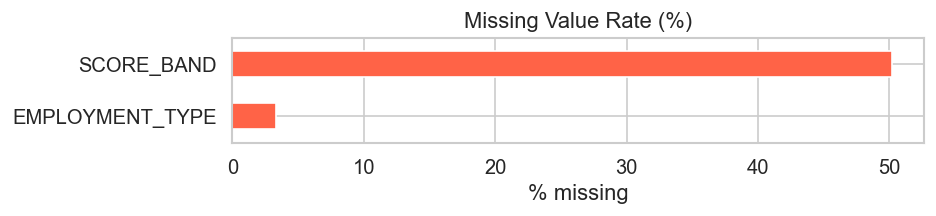


Duplicates: 0


In [23]:
# ============================================================
# 4. Missing Values
# ============================================================
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)

if miss.empty:
    print("✅ No missing values")
else:
    miss_df = pd.DataFrame({
        "missing_count" : miss,
        "missing_%"     : (miss / len(df) * 100).round(2),
    })
    print("Missing Values:")
    display(miss_df)

    # visualise
    fig, ax = plt.subplots(figsize=(8, max(2, len(miss) * 0.5)))
    miss_df["missing_%"].sort_values().plot(kind="barh", ax=ax, color="tomato")
    ax.set_title("Missing Value Rate (%)")
    ax.set_xlabel("% missing")
    plt.tight_layout(); plt.show()

print(f"\nDuplicates: {df.duplicated().sum():,}")


In [56]:
df.isnull().sum().sort_values(ascending=False)

EMPLOYMENT_TYPE                        7661
UNIQUEID                                  0
PRIMARY_INSTAL_AMT                        0
PRI_SANCTIONED_AMOUNT                     0
PRI_DISBURSED_AMOUNT                      0
SEC_NO_OF_ACCTS                           0
SEC_ACTIVE_ACCTS                          0
SEC_OVERDUE_ACCTS                         0
SEC_CURRENT_BALANCE                       0
SEC_SANCTIONED_AMOUNT                     0
SEC_DISBURSED_AMOUNT                      0
SEC_INSTAL_AMT                            0
PRI_OVERDUE_ACCTS                         0
NEW_ACCTS_IN_LAST_SIX_MONTHS              0
DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS       0
AVERAGE_ACCT_AGE                          0
CREDIT_HISTORY_LENGTH                     0
NO_OF_INQUIRIES                           0
LOAN_DEFAULT                              0
AVERAGE_ACCT_AGE_MON                      0
CREDIT_HISTORY_LEN_MON                    0
PRI_CURRENT_BALANCE                       0
PRI_ACTIVE_ACCTS                

In [58]:
# missing rate
print(f"Missing: {df['EMPLOYMENT_TYPE'].isnull().mean():.2%}")

# Default rate ของ missing vs non-missing
df['emp_missing'] = df['EMPLOYMENT_TYPE'].isnull().astype(int)
df.groupby('emp_missing')['LOAN_DEFAULT'].mean()

Missing: 3.29%


emp_missing
0    0.217155
1    0.214593
Name: LOAN_DEFAULT, dtype: float64

In [59]:
# ดูว่า missing เยอะในกลุ่ม Employment ไหน
df[df['EMPLOYMENT_TYPE'].notnull()]['EMPLOYMENT_TYPE'].value_counts(normalize=True)

EMPLOYMENT_TYPE
Self employed    0.566026
Salaried         0.433974
Name: proportion, dtype: float64

In [60]:
df['EMPLOYMENT_TYPE'] = df['EMPLOYMENT_TYPE'].fillna('Unknown')

In [61]:
df.groupby('EMPLOYMENT_TYPE')['LOAN_DEFAULT'].mean().sort_values(ascending=False)

EMPLOYMENT_TYPE
Self employed    0.227657
Unknown          0.214593
Salaried         0.203458
Name: LOAN_DEFAULT, dtype: float64

In [66]:
# Numerical vs Target
df.groupby('LOAN_DEFAULT')['LTV'].describe()

,count,mean,std,min,25%,50%,75%,max
LOAN_DEFAULT,,,,,,,,
0,182543.0,74.154093,11.681455,10.03,68.020,76.00,83.16,95.0
1,50611.0,76.883322,10.327771,15.30,72.055,79.06,84.68,95.0


In [65]:
# Categorical vs Target  
df.groupby('PERFORM_CNS_SCORE_DESCRIPTION')['LOAN_DEFAULT'].mean()

PERFORM_CNS_SCORE_DESCRIPTION
A-Very Low Risk                                            0.165746
B-Very Low Risk                                            0.131290
C-Very Low Risk                                            0.172639
D-Very Low Risk                                            0.149586
E-Low Risk                                                 0.171792
F-Low Risk                                                 0.186211
G-Low Risk                                                 0.197091
H-Medium Risk                                              0.241867
I-Medium Risk                                              0.272629
J-High Risk                                                0.252401
K-High Risk                                                0.278120
L-Very High Risk                                           0.280423
M-Very High Risk                                           0.304581
No Bureau History Available                                0.231313
Not Scored: More t

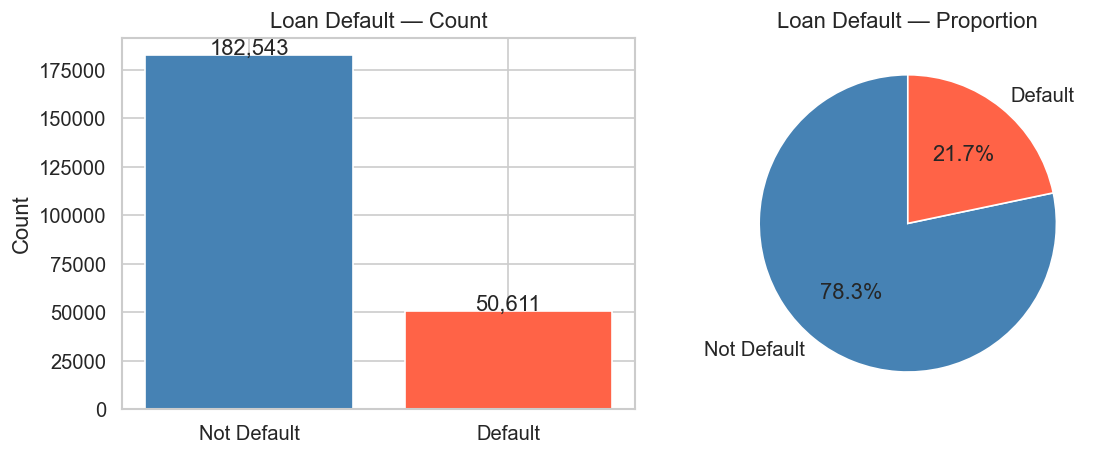

LOAN_DEFAULT
Not Default    182543
Default         50611


In [24]:
# ============================================================
# 5. Target Distribution
# ============================================================
vc = df["LOAN_DEFAULT"].value_counts().rename({0: "Not Default", 1: "Default"})
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(vc.index, vc.values, color=["steelblue", "tomato"])
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center")
axes[0].set_title("Loan Default — Count")
axes[0].set_ylabel("Count")

axes[1].pie(vc.values, labels=vc.index, autopct="%1.1f%%",
            colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Loan Default — Proportion")

plt.tight_layout(); plt.show()
print(vc.to_string())


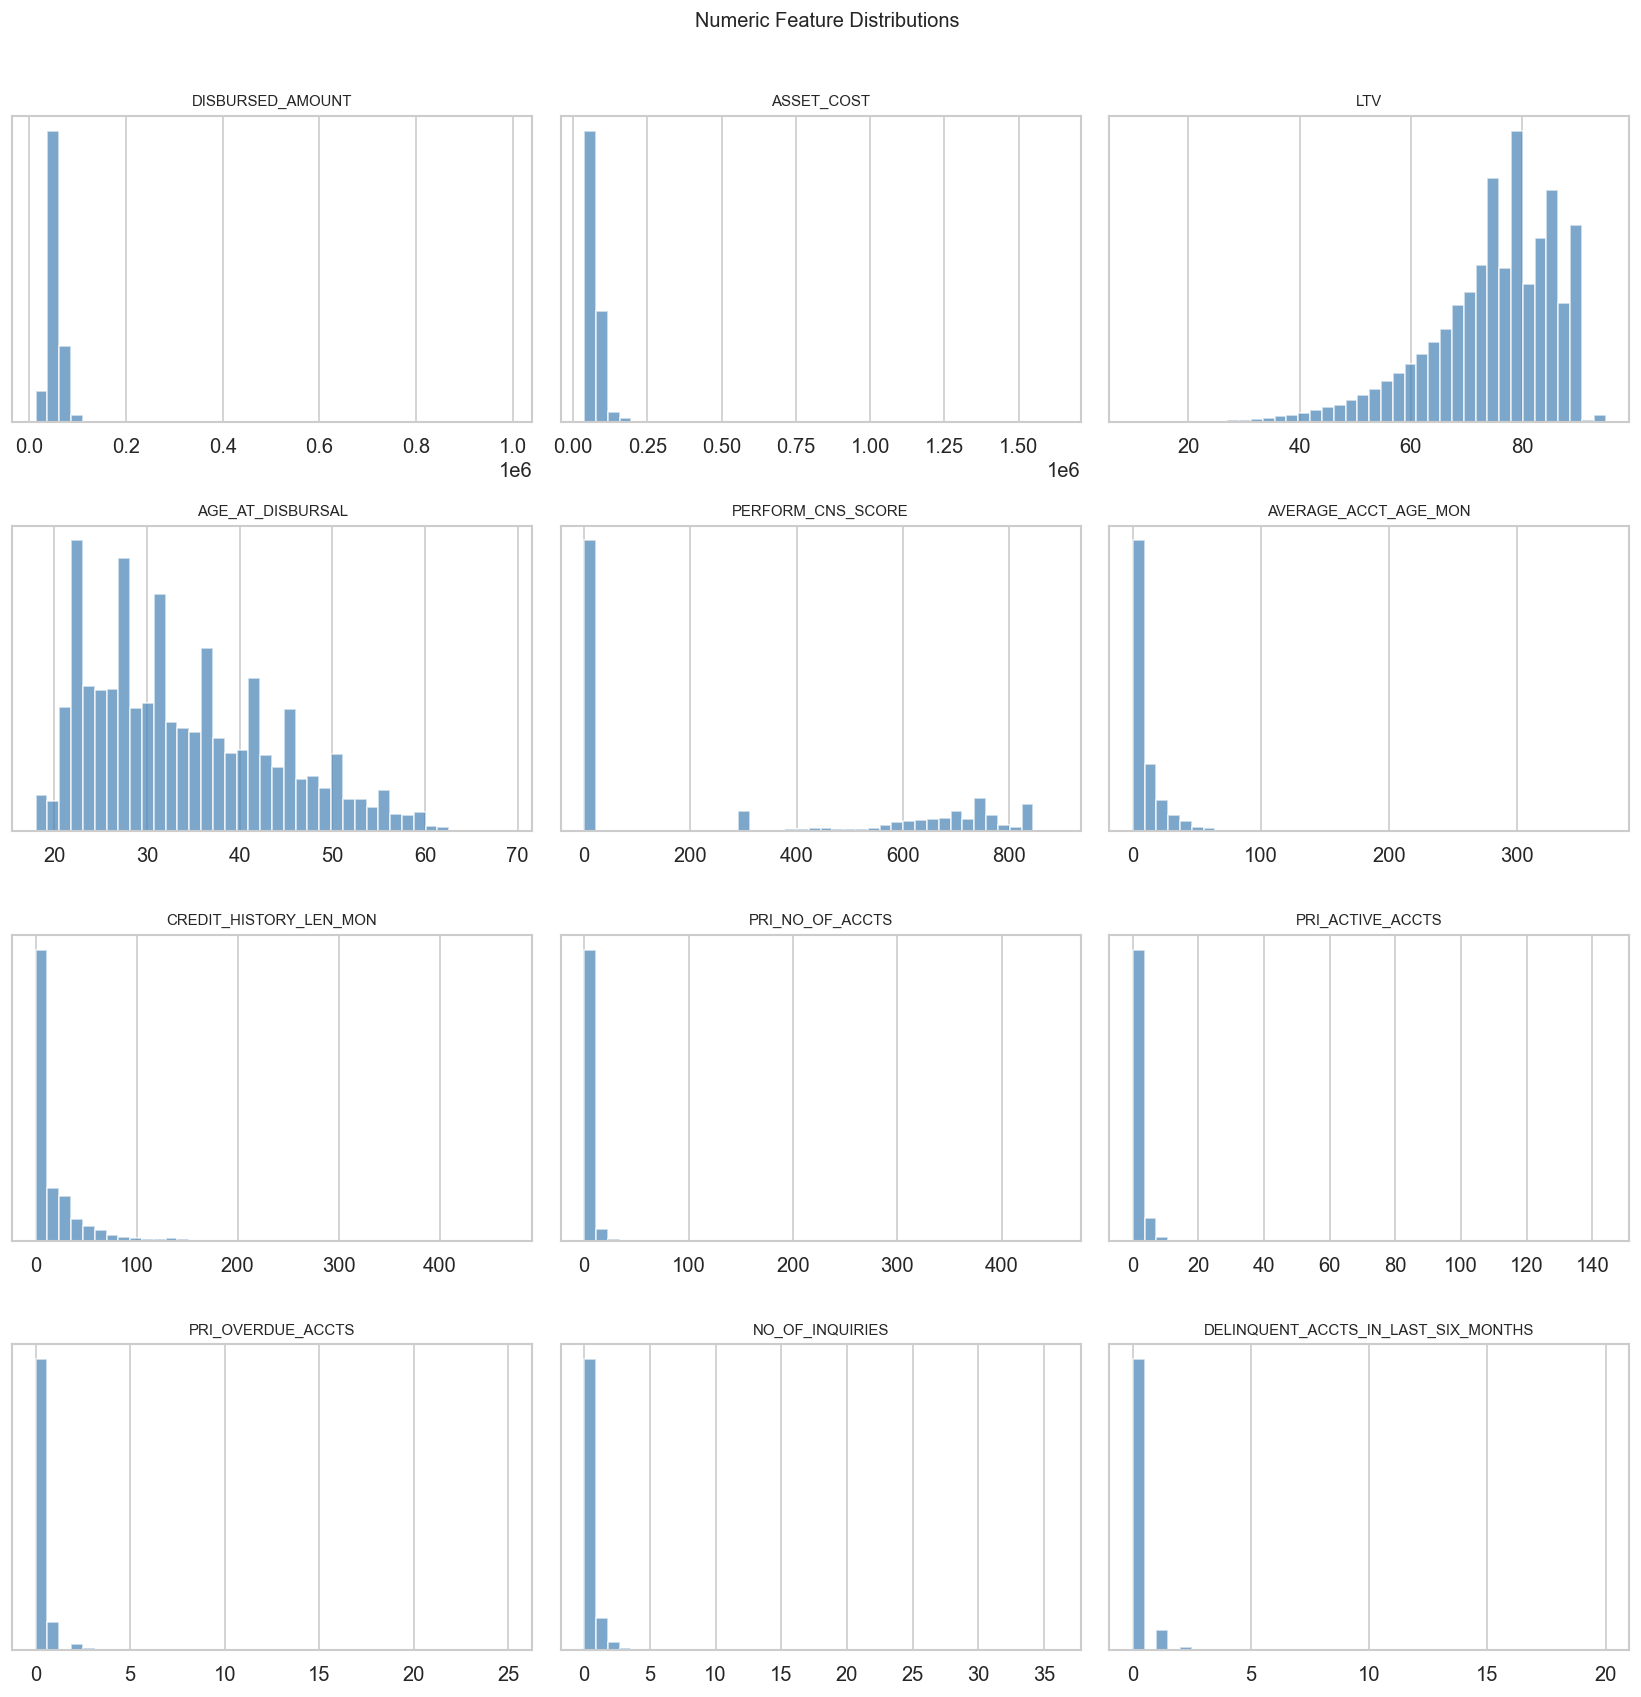

In [25]:
# ============================================================
# 6. Numeric Distributions (histograms + default-rate overlay)
# ============================================================
key_num = [
    "DISBURSED_AMOUNT", "ASSET_COST", "LTV",
    "AGE_AT_DISBURSAL", "PERFORM_CNS_SCORE",
    "AVERAGE_ACCT_AGE_MON", "CREDIT_HISTORY_LEN_MON",
    "PRI_NO_OF_ACCTS", "PRI_ACTIVE_ACCTS", "PRI_OVERDUE_ACCTS",
    "NO_OF_INQUIRIES", "DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS",
]

n_cols = 3
n_rows = -(-len(key_num) // n_cols)   # ceiling div
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(key_num):
    axes[i].hist(df[col].dropna(), bins=40, color="steelblue",
                 edgecolor="white", density=True, alpha=0.7)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_yticks([])

# hide unused
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions", y=1.01, fontsize=12)
plt.tight_layout(); plt.show()


In [26]:
# ============================================================
# 7. Categorical Summary
# ============================================================
cat_cols = ["EMPLOYMENT_TYPE", "PERFORM_CNS_SCORE_DESCRIPTION"]

for col in cat_cols:
    vc = df[col].value_counts(dropna=False)
    dr = df.groupby(col, dropna=False)["LOAN_DEFAULT"].mean().rename("default_rate")
    summary = pd.concat([vc.rename("count"), dr], axis=1)
    summary["count_%"] = (summary["count"] / len(df) * 100).round(1)
    print(f"\n── {col} ──")
    display(summary.sort_values("count", ascending=False))



── EMPLOYMENT_TYPE ──


,count,default_rate,count_%
EMPLOYMENT_TYPE,,,
Self employed,127635,0.227657,54.7
Salaried,97858,0.203458,42.0
NaN,7661,0.214593,3.3



── PERFORM_CNS_SCORE_DESCRIPTION ──


,count,default_rate,count_%
PERFORM_CNS_SCORE_DESCRIPTION,,,
No Bureau History Available,116950,0.231313,50.2
C-Very Low Risk,16045,0.172639,6.9
A-Very Low Risk,14124,0.165746,6.1
D-Very Low Risk,11358,0.149586,4.9
B-Very Low Risk,9201,0.131290,3.9
M-Very High Risk,8776,0.304581,3.8
F-Low Risk,8485,0.186211,3.6
K-High Risk,8277,0.278120,3.6
H-Medium Risk,6855,0.241867,2.9


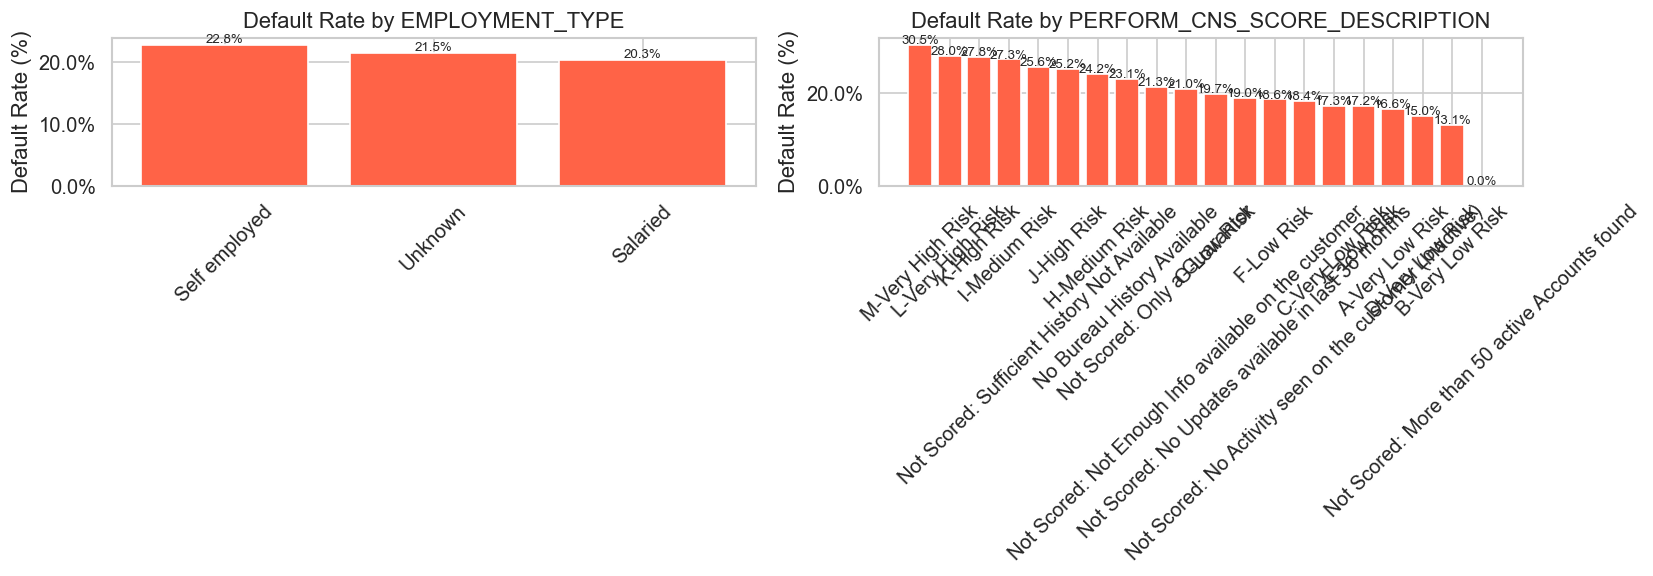

In [73]:
# ============================================================
# 8. Default Rate by Key Categorical Features (bar chart)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_cols):
    # fill NaN ก่อน groupby เพื่อป้องกัน float index
    dr = (df[col].fillna("(Missing)")
            .pipe(lambda s: df.assign(**{col: s}))
            .groupby(col)["LOAN_DEFAULT"].mean()
            .sort_values(ascending=False))
    
    ax.bar(dr.index.astype(str), dr.values * 100, color="tomato")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f"Default Rate by {col}")
    ax.set_ylabel("Default Rate (%)")
    ax.tick_params(axis="x", rotation=45)
    for j, v in enumerate(dr.values):
        ax.text(j, v * 100 + 0.3, f"{v:.1%}", ha="center", fontsize=8)

plt.tight_layout(); plt.show()


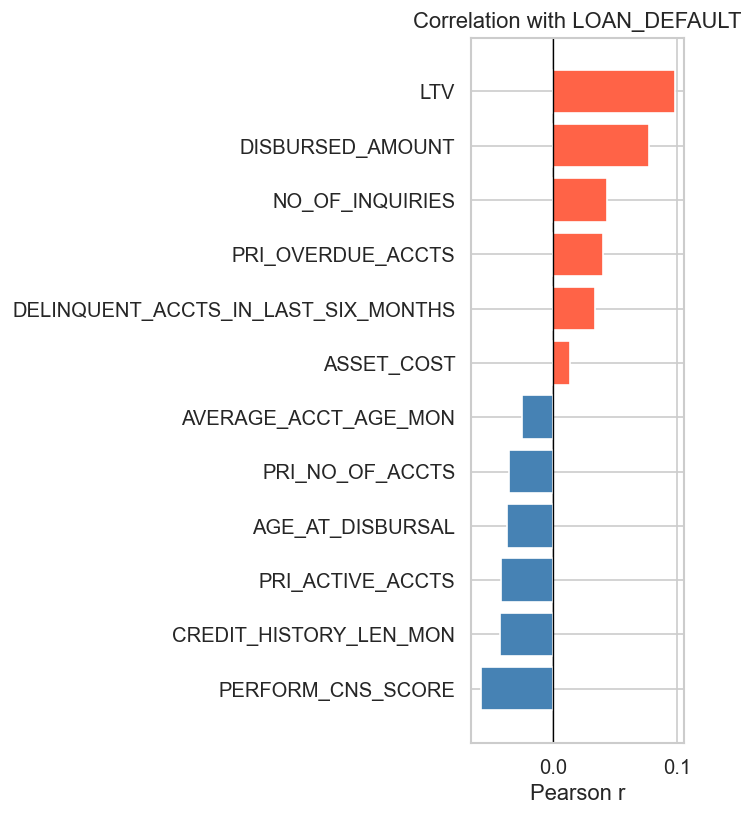

PERFORM_CNS_SCORE                     -0.057929
CREDIT_HISTORY_LEN_MON                -0.042126
PRI_ACTIVE_ACCTS                      -0.041451
AGE_AT_DISBURSAL                      -0.036549
PRI_NO_OF_ACCTS                       -0.035456
AVERAGE_ACCT_AGE_MON                  -0.024781
ASSET_COST                             0.014261
DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS    0.034462
PRI_OVERDUE_ACCTS                      0.040872
NO_OF_INQUIRIES                        0.043678
DISBURSED_AMOUNT                       0.077675
LTV                                    0.098208


In [30]:
# ============================================================
# 9. Correlation Heatmap (numeric cols vs target)
# ============================================================
corr_cols = key_num + ["LOAN_DEFAULT"]
corr = df[corr_cols].corr()["LOAN_DEFAULT"].drop("LOAN_DEFAULT").sort_values()

fig, ax = plt.subplots(figsize=(6, len(corr) * 0.5 + 1))
colors = ["tomato" if v > 0 else "steelblue" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation with LOAN_DEFAULT")
ax.set_xlabel("Pearson r")
plt.tight_layout(); plt.show()
print(corr.to_string())


In [74]:
df.select_dtypes(include='number').corr()

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,STATE_ID,EMPLOYEE_CODE_ID,...,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,NO_OF_INQUIRIES,LOAN_DEFAULT,AVERAGE_ACCT_AGE_MON,CREDIT_HISTORY_LEN_MON,AGE_AT_DISBURSAL,emp_missing
UNIQUEID,1.000000,0.145575,0.144671,-0.030537,-0.004509,0.025747,-0.021514,0.030500,-0.057734,0.075983,...,-0.009321,-0.013518,-0.003842,-0.009186,0.016537,0.033848,-0.011912,-0.018799,0.010072,0.019069
DISBURSED_AMOUNT,0.145575,1.000000,0.752668,0.376747,0.018328,0.078596,0.095203,0.068540,-0.023956,0.010120,...,0.002350,-0.005525,0.035880,0.020198,0.038513,0.077675,0.004205,0.013402,-0.059193,0.048628
ASSET_COST,0.144671,0.752668,1.000000,-0.301188,0.018586,0.150002,-0.005256,0.275878,-0.026348,0.008711,...,-0.004356,-0.005738,-0.021968,-0.007932,-0.017301,0.014261,-0.015614,-0.023563,-0.117898,0.066994
LTV,-0.030537,0.376747,-0.301188,1.000000,0.006382,-0.103732,0.121003,-0.300112,0.004882,0.004940,...,0.007358,0.000481,0.083824,0.041921,0.085725,0.098208,0.029853,0.053607,0.081010,-0.028462
BRANCH_ID,-0.004509,0.018328,0.018586,0.006382,1.000000,0.225744,-0.049957,0.048192,0.187782,0.088764,...,0.004955,0.004265,-0.008354,-0.001730,-0.001813,0.030193,0.005338,-0.002577,-0.003335,-0.010451
SUPPLIER_ID,0.025747,0.078596,0.150002,-0.103732,0.225744,1.000000,-0.063916,0.187401,0.105502,0.095792,...,-0.011953,-0.005826,-0.053264,-0.024622,-0.030988,0.027357,-0.034095,-0.061370,-0.033905,-0.010818
MANUFACTURER_ID,-0.021514,0.095203,-0.005256,0.121003,-0.049957,-0.063916,1.000000,-0.104349,0.026412,-0.045009,...,0.014116,0.003020,0.050079,0.019438,0.010012,-0.025039,0.042522,0.061534,0.056123,-0.010829
CURRENT_PINCODE_ID,0.030500,0.068540,0.275878,-0.300112,0.048192,0.187401,-0.104349,1.000000,0.047903,-0.042609,...,0.002275,-0.006305,-0.100080,-0.057419,-0.058821,0.028419,-0.062704,-0.095906,-0.070329,0.051297
STATE_ID,-0.057734,-0.023956,-0.026348,0.004882,0.187782,0.105502,0.026412,0.047903,1.000000,0.117309,...,0.015843,0.009850,-0.014942,-0.000655,-0.016129,0.048075,-0.008205,-0.014526,0.020778,0.025046
EMPLOYEE_CODE_ID,0.075983,0.010120,0.008711,0.004940,0.088764,0.095792,-0.045009,-0.042609,0.117309,1.000000,...,0.013470,0.001894,0.005473,0.003624,-0.002108,0.020657,0.000297,0.002189,0.012590,-0.006610


---
## 📊 Group 1 — Affordability (ความสามารถชำระหนี้)
> *ไม่มีข้อมูล income ใน dataset นี้ → ใช้ `LTV` และ bureau debt load เป็น proxy*

**สมมติฐาน:** LTV > 85% จะมี default rate สูงขึ้นชัดเจน

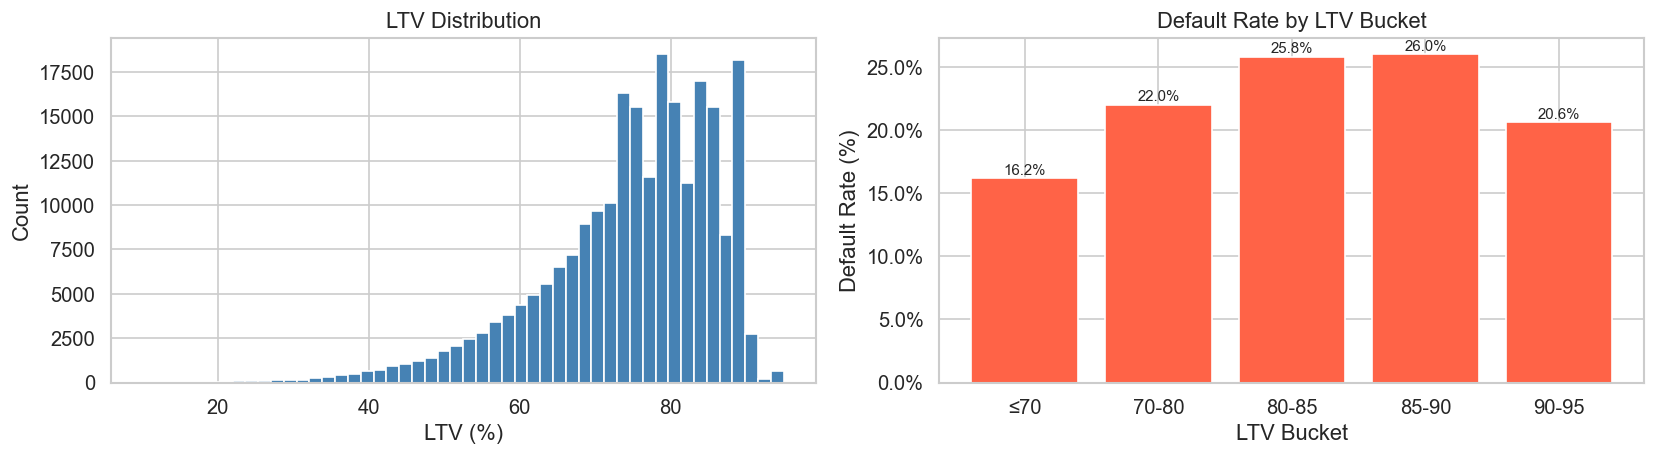

LTV_BIN  default_rate  count
    ≤70      0.161981  65662
  70-80      0.219931  85604
  80-85      0.257949  45982
  85-90      0.259972  35023
  90-95      0.206116    883


In [4]:
# Q1-A: LTV distribution + default rate by bucket
df["LTV_BIN"] = pd.cut(df["LTV"], bins=[0,70,80,85,90,95,100,200],
                        labels=["≤70","70-80","80-85","85-90","90-95","95-100",">100"])

ltv_dr = df.groupby("LTV_BIN", observed=True)["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
ltv_dr.columns = ["LTV_BIN","default_rate","count"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# histogram
axes[0].hist(df["LTV"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set(title="LTV Distribution", xlabel="LTV (%)", ylabel="Count")

# default rate by bucket
axes[1].bar(ltv_dr["LTV_BIN"].astype(str), ltv_dr["default_rate"]*100, color="tomato")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set(title="Default Rate by LTV Bucket", xlabel="LTV Bucket", ylabel="Default Rate (%)")
for i, row in ltv_dr.iterrows():
    axes[1].text(i, row["default_rate"]*100 + 0.3, f"{row['default_rate']:.1%}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print(ltv_dr.to_string(index=False))

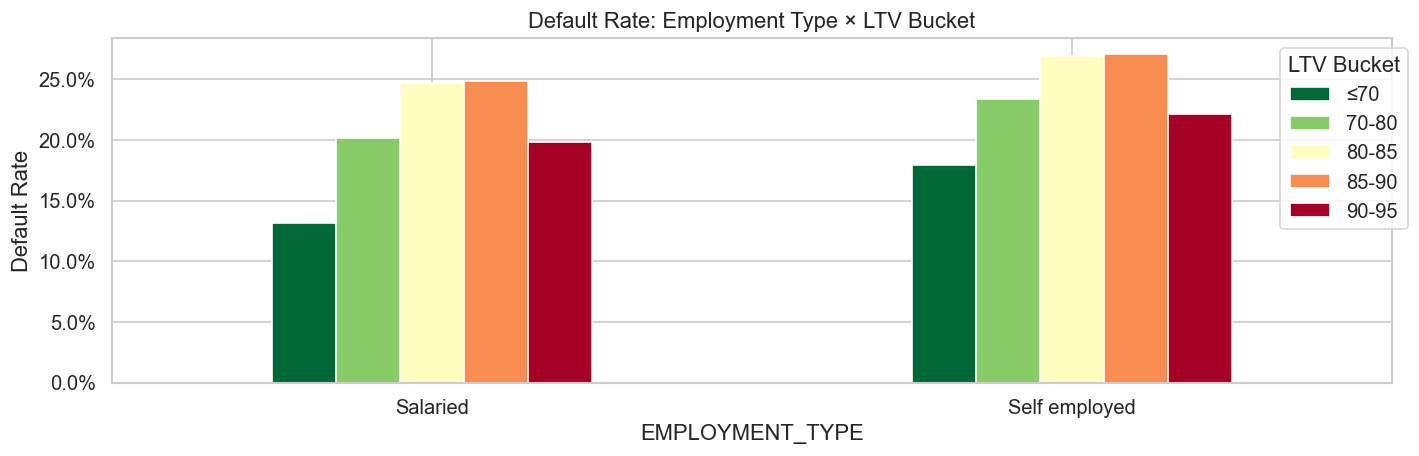

In [5]:
# Q1-B: Employment Type → LTV → Default Rate (3-way view)
emp_ltv = df.groupby(["EMPLOYMENT_TYPE","LTV_BIN"], observed=True)["LOAN_DEFAULT"].mean().unstack()
emp_ltv.plot(kind="bar", figsize=(12,4), colormap="RdYlGn_r")
plt.title("Default Rate: Employment Type × LTV Bucket")
plt.ylabel("Default Rate"); plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(title="LTV Bucket", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()

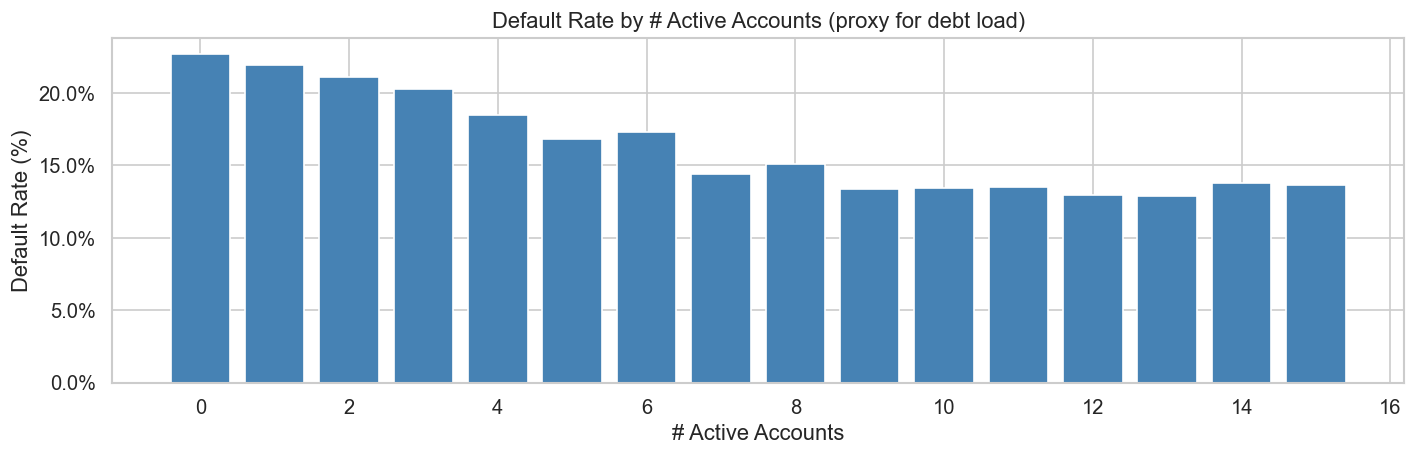

In [6]:
# Q1-C: Existing debt burden proxy
df["TOTAL_ACTIVE_ACCTS"] = df["PRI_ACTIVE_ACCTS"] + df["SEC_ACTIVE_ACCTS"]
debt_dr = df.groupby("TOTAL_ACTIVE_ACCTS")["LOAN_DEFAULT"].agg(["mean","count"])
debt_dr = debt_dr[debt_dr["count"] >= 100].reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(debt_dr["TOTAL_ACTIVE_ACCTS"], debt_dr["mean"]*100, color="steelblue")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Default Rate by # Active Accounts (proxy for debt load)",
       xlabel="# Active Accounts", ylabel="Default Rate (%)")
plt.tight_layout(); plt.show()

---
## 🚙 Group 2 — Collateral (คุณภาพหลักประกัน)
**สมมติฐาน:** ยี่ห้อรถราคาแพง (manufacturer_id ที่มี asset_cost สูง) จะมี default ต่ำ  
แต่คาดว่าเป็นเพราะลูกค้ากลุ่มนั้นรวยกว่า ไม่ใช่เพราะตัวรถ

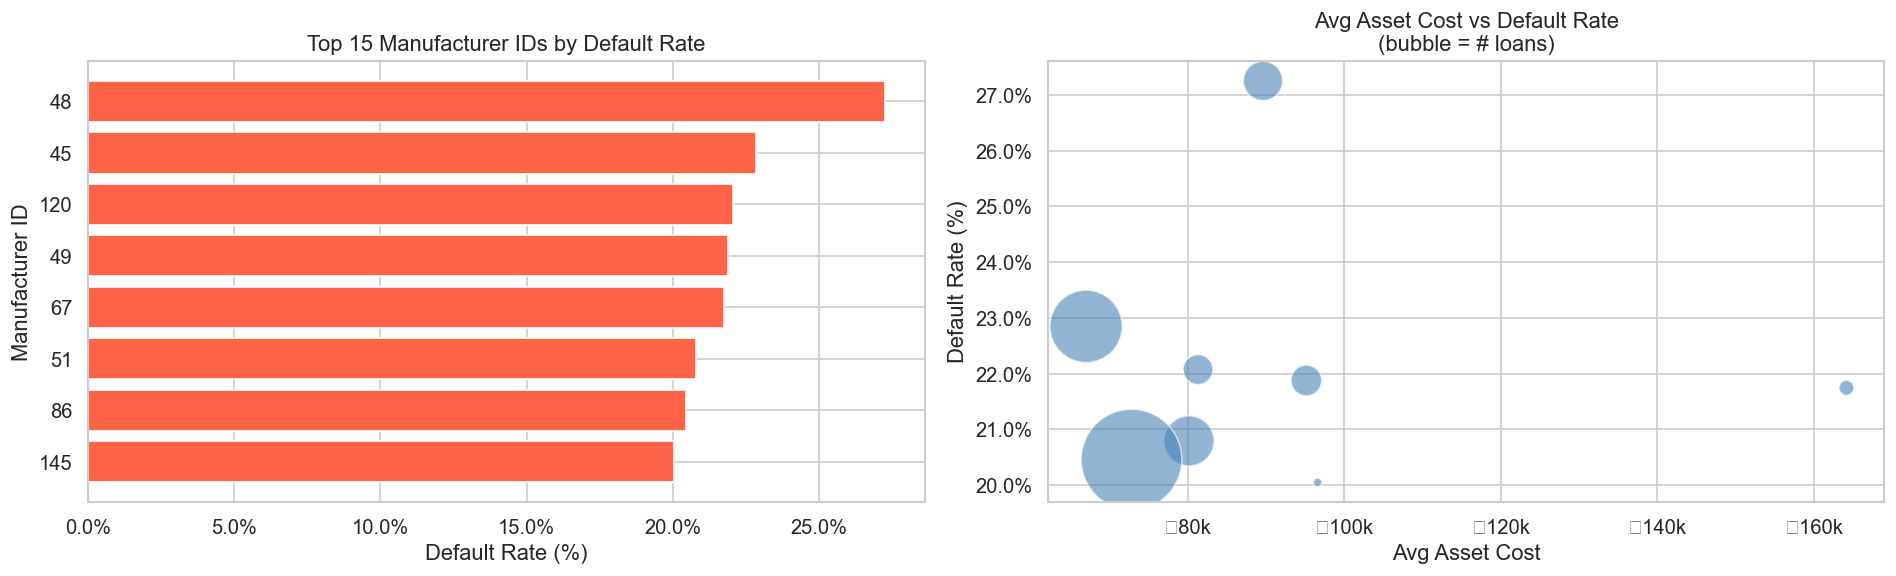

In [7]:
# Q2-A: manufacturer default rate + avg asset cost
mfr = df.groupby("MANUFACTURER_ID").agg(
    default_rate=("LOAN_DEFAULT","mean"),
    avg_cost=("ASSET_COST","mean"),
    count=("LOAN_DEFAULT","count")
).reset_index()
mfr = mfr[mfr["count"] >= 200].sort_values("default_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_mfr = mfr.head(15)
axes[0].barh(top_mfr["MANUFACTURER_ID"].astype(str), top_mfr["default_rate"]*100, color="tomato")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set(title="Top 15 Manufacturer IDs by Default Rate", xlabel="Default Rate (%)", ylabel="Manufacturer ID")
axes[0].invert_yaxis()

axes[1].scatter(mfr["avg_cost"], mfr["default_rate"]*100, s=mfr["count"]/30,
                alpha=0.6, color="steelblue", edgecolors="white")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"₹{x/1000:.0f}k"))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set(title="Avg Asset Cost vs Default Rate\n(bubble = # loans)",
            xlabel="Avg Asset Cost", ylabel="Default Rate (%)")
plt.tight_layout(); plt.show()

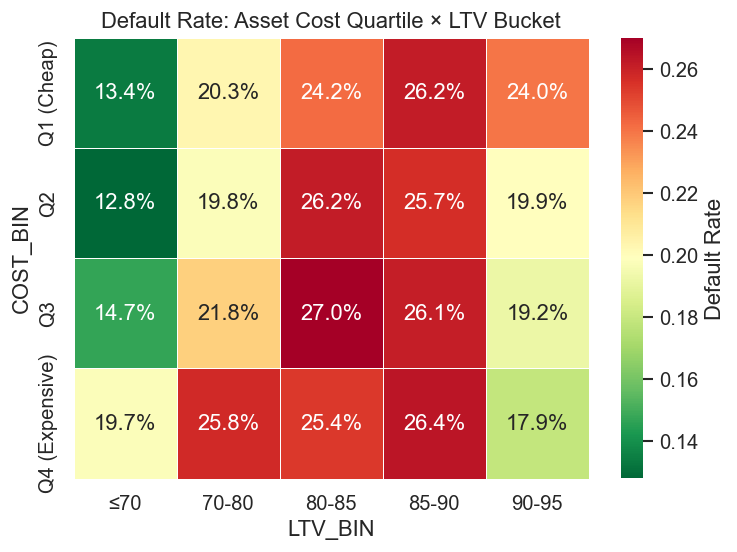

In [8]:
# Q2-B: LTV bucketed → asset cost bucket interaction
df["COST_BIN"] = pd.qcut(df["ASSET_COST"], q=4, labels=["Q1 (Cheap)","Q2","Q3","Q4 (Expensive)"])
pivot = df.groupby(["COST_BIN","LTV_BIN"], observed=True)["LOAN_DEFAULT"].mean().unstack()
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn_r", linewidths=0.5,
            cbar_kws={"label":"Default Rate"})
plt.title("Default Rate: Asset Cost Quartile × LTV Bucket")
plt.tight_layout(); plt.show()

---
## 💳 Group 3 — Credit Behavior (ประวัติพฤติกรรมเครดิต)
กลุ่มนี้ให้ predictive power สูงสุดใน dataset นี้  
**สมมติฐาน:** ลูกค้าที่ `PERFORM_CNS_SCORE = 0` (ไม่มีประวัติ) อาจเสี่ยงกว่าคนที่ score ต่ำด้วยซ้ำ

ลูกค้าที่ไม่มีประวัติเครดิต (score=0): 116,950 (50.2%)
Default rate ไม่มีประวัติ : 23.13%
Default rate มีประวัติ    : 20.27%


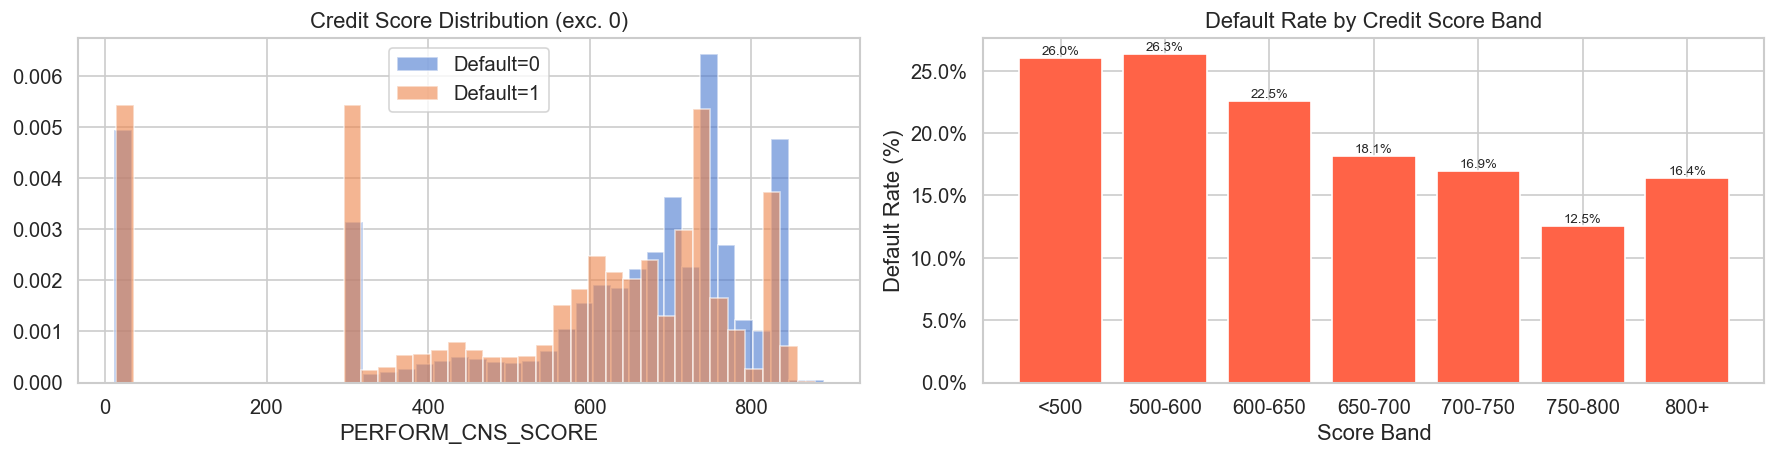

In [9]:
# Q3-A: Credit Score distribution by default
score_no_hist = df["PERFORM_CNS_SCORE"] == 0
print(f"ลูกค้าที่ไม่มีประวัติเครดิต (score=0): {score_no_hist.sum():,} ({score_no_hist.mean():.1%})")
print(f"Default rate ไม่มีประวัติ : {df[score_no_hist]['LOAN_DEFAULT'].mean():.2%}")
print(f"Default rate มีประวัติ    : {df[~score_no_hist]['LOAN_DEFAULT'].mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
# Distribution
for label, grp in df[~score_no_hist].groupby("LOAN_DEFAULT"):
    axes[0].hist(grp["PERFORM_CNS_SCORE"], bins=40, alpha=0.6,
                 label=f"Default={label}", density=True)
axes[0].set(title="Credit Score Distribution (exc. 0)", xlabel="PERFORM_CNS_SCORE")
axes[0].legend()

# Score band default rate
df["SCORE_BAND"] = pd.cut(df["PERFORM_CNS_SCORE"], bins=[0,1,500,600,650,700,750,800,900],
    labels=["No Hist","<500","500-600","600-650","650-700","700-750","750-800","800+"])
band_dr = df.groupby("SCORE_BAND", observed=True)["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
axes[1].bar(band_dr["SCORE_BAND"].astype(str), band_dr["mean"]*100, color="tomato")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set(title="Default Rate by Credit Score Band", xlabel="Score Band", ylabel="Default Rate (%)")
for i, row in band_dr.iterrows():
    axes[1].text(i, row["mean"]*100+0.3, f"{row['mean']:.1%}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

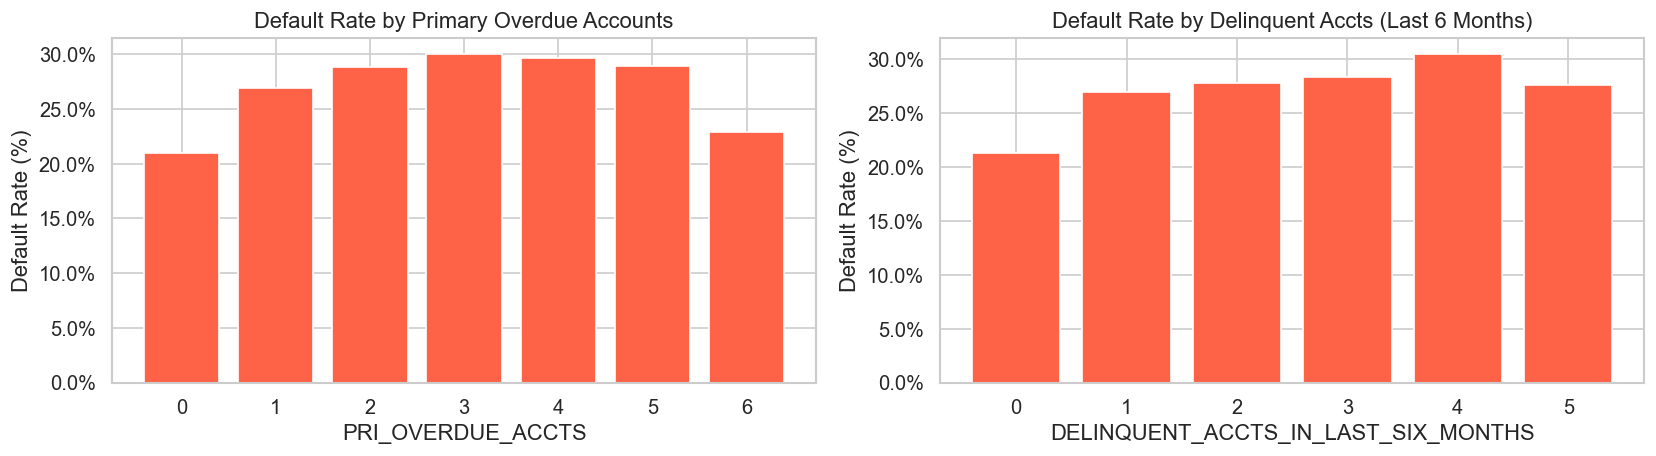

In [10]:
# Q3-B: Overdue accounts ทำนาย default ได้แค่ไหน
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in zip(axes,
    ["PRI_OVERDUE_ACCTS","DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS"],
    ["Primary Overdue Accounts","Delinquent Accts (Last 6 Months)"]):
    tmp = df.groupby(col)["LOAN_DEFAULT"].agg(["mean","count"])
    tmp = tmp[tmp["count"] >= 50].reset_index()
    ax.bar(tmp[col], tmp["mean"]*100, color="tomato")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set(title=f"Default Rate by {title}", xlabel=col, ylabel="Default Rate (%)")
plt.tight_layout(); plt.show()


Default rate by secondary loan status:
                               Default Rate   Count
Primary Loans Only                 0.217527  229337
Has Secondary/Guarantor Loans      0.189678    3817


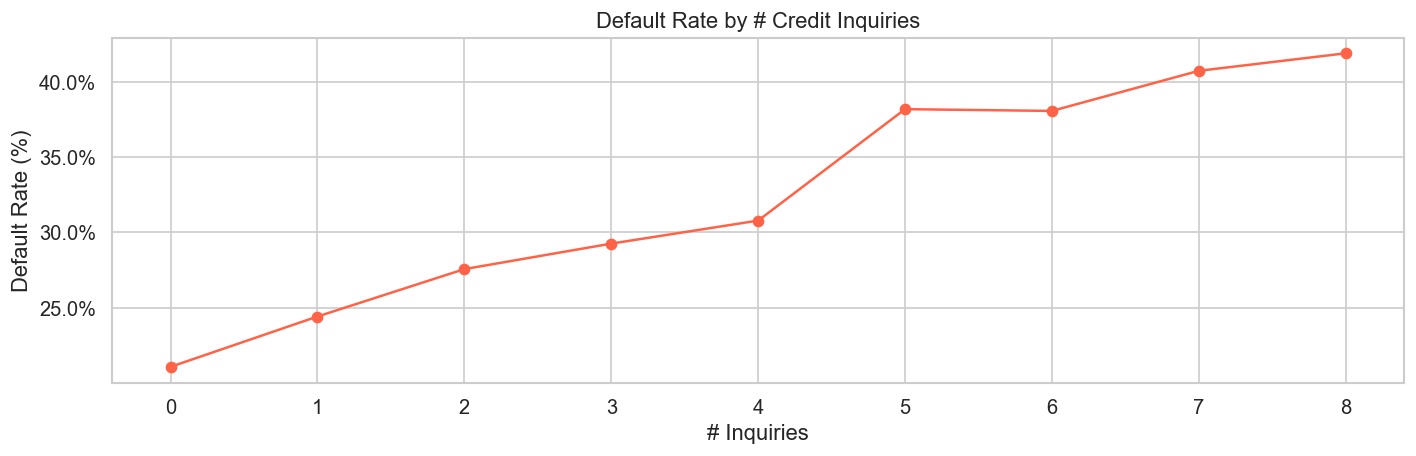

In [11]:
# Q3-C: Multiple active accounts → higher debt burden?
df["HAS_SEC_LOAN"] = (df["SEC_ACTIVE_ACCTS"] > 0).astype(int)
cross = df.groupby("HAS_SEC_LOAN")["LOAN_DEFAULT"].agg(["mean","count"])
cross.index = ["Primary Loans Only","Has Secondary/Guarantor Loans"]
print("\nDefault rate by secondary loan status:")
print(cross.rename(columns={"mean":"Default Rate","count":"Count"}).to_string())

# Q3-D: Inquiry count → default
inq = df.groupby("NO_OF_INQUIRIES")["LOAN_DEFAULT"].agg(["mean","count"])
inq = inq[inq["count"] >= 100].reset_index()
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(inq["NO_OF_INQUIRIES"], inq["mean"]*100, marker="o", color="tomato")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Default Rate by # Credit Inquiries", xlabel="# Inquiries", ylabel="Default Rate (%)")
plt.tight_layout(); plt.show()

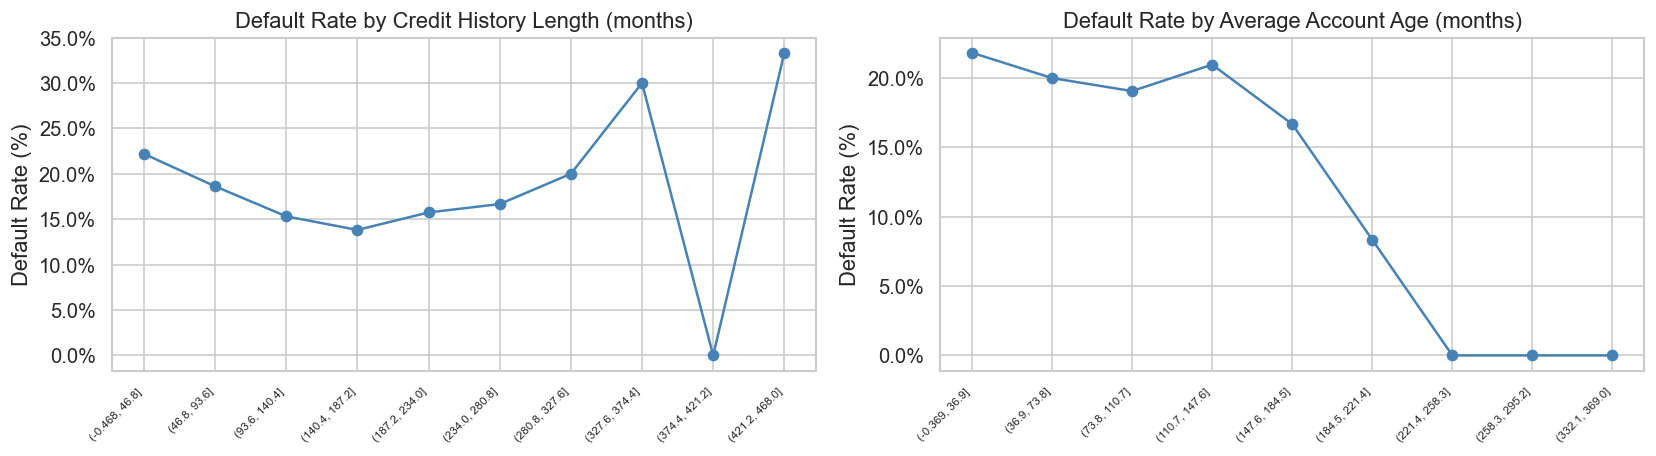

In [12]:
# Q3-E: Credit history length vs default
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in zip(axes,
    ["CREDIT_HISTORY_LEN_MON","AVERAGE_ACCT_AGE_MON"],
    ["Credit History Length (months)","Average Account Age (months)"]):
    df["_tmp_bin"] = pd.cut(df[col], bins=10)
    tmp = df.groupby("_tmp_bin", observed=True)["LOAN_DEFAULT"].mean().reset_index()
    ax.plot(range(len(tmp)), tmp["LOAN_DEFAULT"]*100, marker="o", color="steelblue")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xticks(range(len(tmp)))
    ax.set_xticklabels([str(x) for x in tmp["_tmp_bin"]], rotation=45, ha="right", fontsize=7)
    ax.set(title=f"Default Rate by {title}", ylabel="Default Rate (%)")
df.drop(columns=["_tmp_bin"], inplace=True)
plt.tight_layout(); plt.show()

---
## 📅 Group 4 — Temporal Patterns
**สมมติฐาน:** vintage บางปีมี default ผิดปกติ (external shock เช่น เศรษฐกิจ/โรคระบาด)

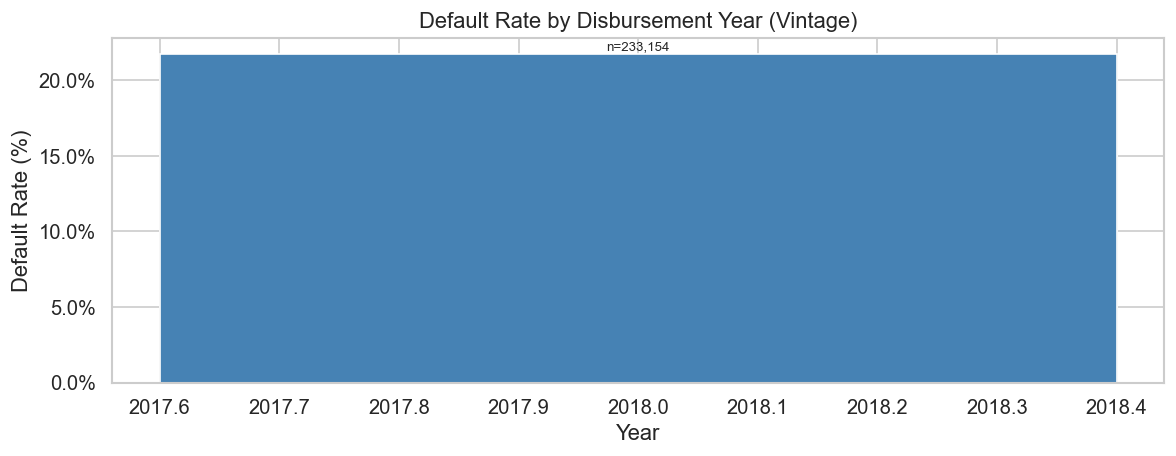

In [13]:
# Q4-A: Default rate by disbursement year (vintage)
df["DISBURSAL_YEAR"]  = df["DISBURSAL_DATE"].dt.year
df["DISBURSAL_MONTH"] = df["DISBURSAL_DATE"].dt.to_period("M").astype(str)

vintage = df.groupby("DISBURSAL_YEAR")["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(vintage["DISBURSAL_YEAR"], vintage["mean"]*100, color="steelblue")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Default Rate by Disbursement Year (Vintage)",
       xlabel="Year", ylabel="Default Rate (%)")
for bar, cnt in zip(bars, vintage["count"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"n={cnt:,}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

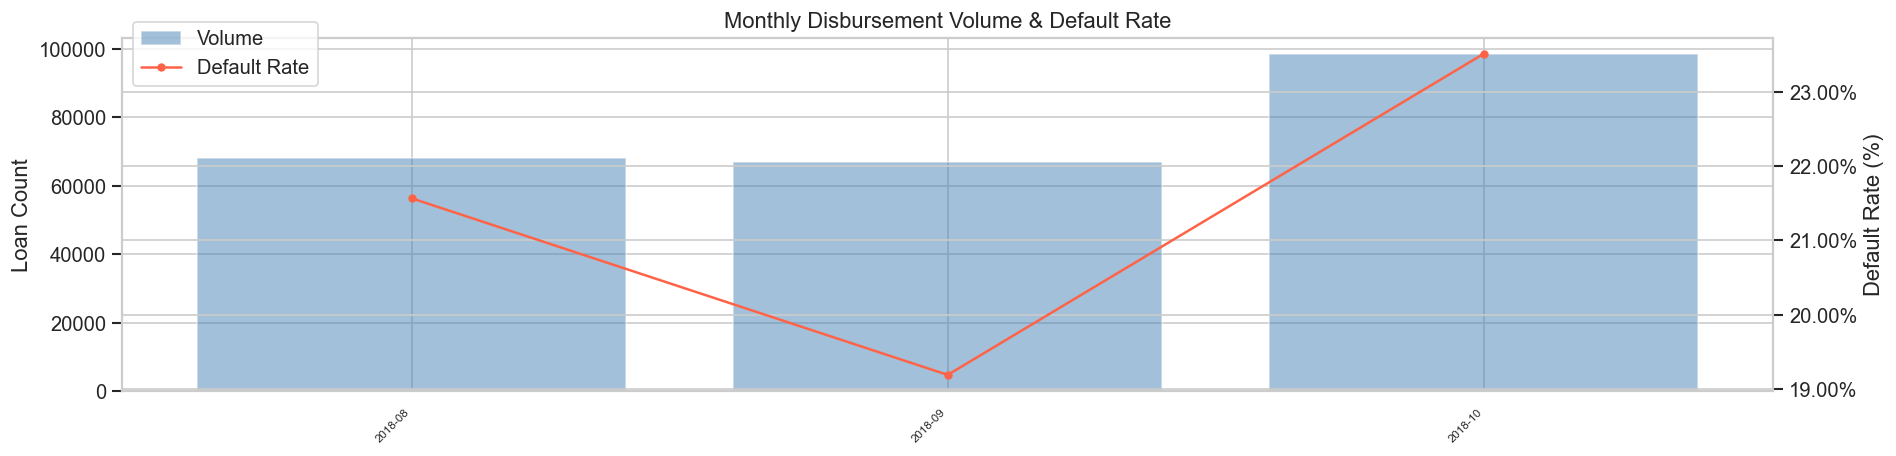

In [14]:
# Q4-B: Monthly volume + default rate trend
monthly = df.groupby("DISBURSAL_MONTH").agg(
    count=("LOAN_DEFAULT","count"),
    default_rate=("LOAN_DEFAULT","mean")
).reset_index().sort_values("DISBURSAL_MONTH")

fig, ax1 = plt.subplots(figsize=(16, 4))
ax2 = ax1.twinx()
ax1.bar(range(len(monthly)), monthly["count"], color="steelblue", alpha=0.5, label="Volume")
ax2.plot(range(len(monthly)), monthly["default_rate"]*100, color="tomato", marker="o", ms=4, label="Default Rate")
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly["DISBURSAL_MONTH"], rotation=45, ha="right", fontsize=7)
ax1.set_ylabel("Loan Count"); ax2.set_ylabel("Default Rate (%)")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_title("Monthly Disbursement Volume & Default Rate")
fig.legend(loc="upper left", bbox_to_anchor=(0.07, 0.95))
plt.tight_layout(); plt.show()

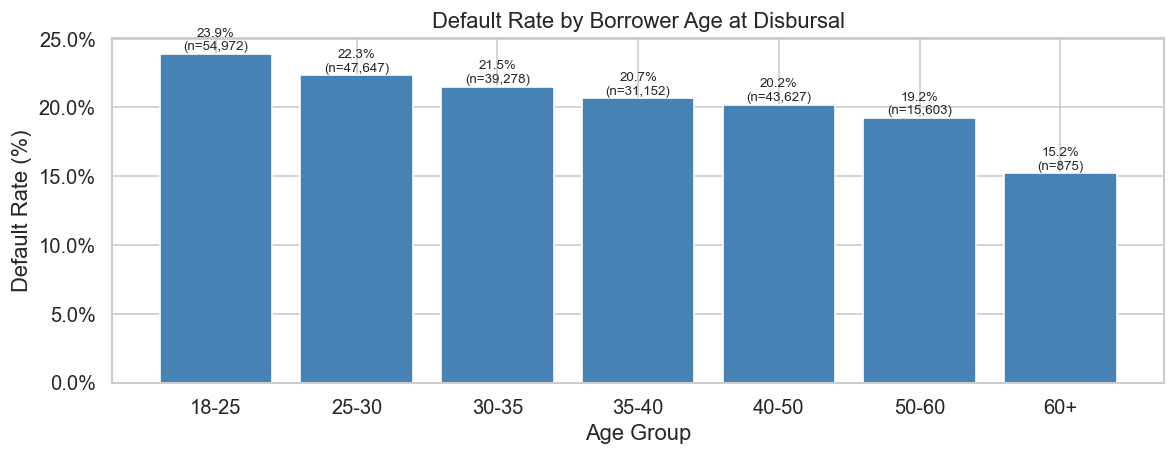

In [15]:
# Q4-C: Age of borrower at disbursal vs default
df["AGE_BIN"] = pd.cut(df["AGE_AT_DISBURSAL"], bins=[17,25,30,35,40,50,60,100],
                        labels=["18-25","25-30","30-35","35-40","40-50","50-60","60+"])
age_dr = df.groupby("AGE_BIN", observed=True)["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(age_dr["AGE_BIN"].astype(str), age_dr["mean"]*100, color="steelblue")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Default Rate by Borrower Age at Disbursal",
       xlabel="Age Group", ylabel="Default Rate (%)")
for i, row in age_dr.iterrows():
    ax.text(i, row["mean"]*100+0.3, f"{row['mean']:.1%}\n(n={row['count']:,})", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

---
## 🔀 Group 5 — Segment Interactions
**สมมติฐาน:** Risk factors "คูณกัน" ไม่ใช่ "บวกกัน" — ลูกค้าที่มีหลาย risk factor พร้อมกัน จะ default สูงมากกว่าที่คาด


Interaction: LTV × Overdue Accounts
               label  Default Rate      N
 LTV≤85 + No Overdue      0.202601 175730
LTV≤85 + Has Overdue      0.265870  21518
 LTV>85 + No Overdue      0.250570  31149
LTV>85 + Has Overdue      0.311541   4757


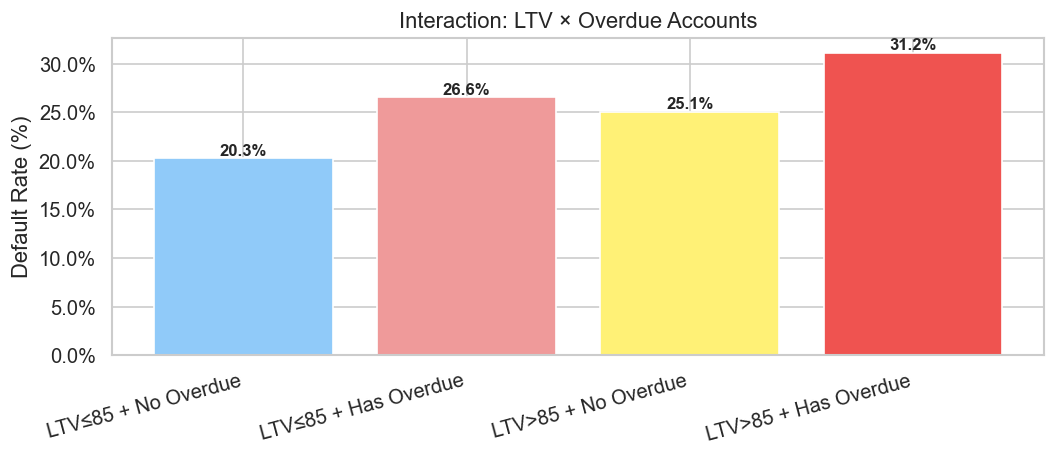

In [16]:
# Q5-A: LTV HIGH × Overdue accounts — do risks multiply?
df["LTV_HIGH"]     = (df["LTV"] > 85).astype(int)
df["HAS_OVERDUE"]  = (df["PRI_OVERDUE_ACCTS"] > 0).astype(int)

combo = df.groupby(["LTV_HIGH","HAS_OVERDUE"])["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
combo["label"] = combo.apply(
    lambda r: f"LTV{'≤' if r['LTV_HIGH']==0 else '>'}85 + {'No' if r['HAS_OVERDUE']==0 else 'Has'} Overdue", axis=1)
print("\nInteraction: LTV × Overdue Accounts")
print(combo[["label","mean","count"]].rename(columns={"mean":"Default Rate","count":"N"}).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#90CAF9","#EF9A9A","#FFF176","#EF5350"]
bars = ax.bar(combo["label"], combo["mean"]*100, color=colors)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Interaction: LTV × Overdue Accounts", ylabel="Default Rate (%)")
for bar, row in zip(bars, combo.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{row.mean:.1%}", ha="center", fontsize=10, fontweight="bold")
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()

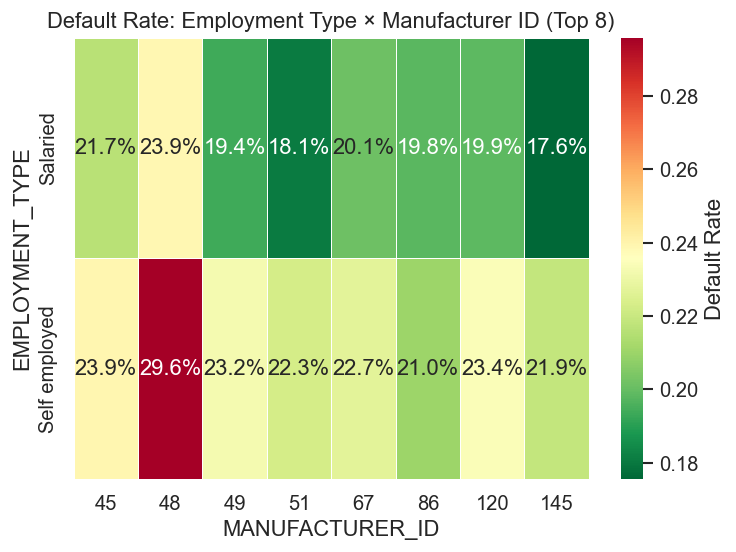

In [17]:
# Q5-B: Employment Type × Manufacturer → Profiling
# ถ้ายี่ห้อเดียวกัน แต่ประเภทอาชีพต่างกัน default rate ต่างกันไหม?
top_mfr_ids = df["MANUFACTURER_ID"].value_counts().head(8).index
sub = df[df["MANUFACTURER_ID"].isin(top_mfr_ids)]
pivot = sub.groupby(["EMPLOYMENT_TYPE","MANUFACTURER_ID"])["LOAN_DEFAULT"].mean().unstack()

sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn_r", linewidths=0.5,
            cbar_kws={"label":"Default Rate"})
plt.title("Default Rate: Employment Type × Manufacturer ID (Top 8)")
plt.tight_layout(); plt.show()

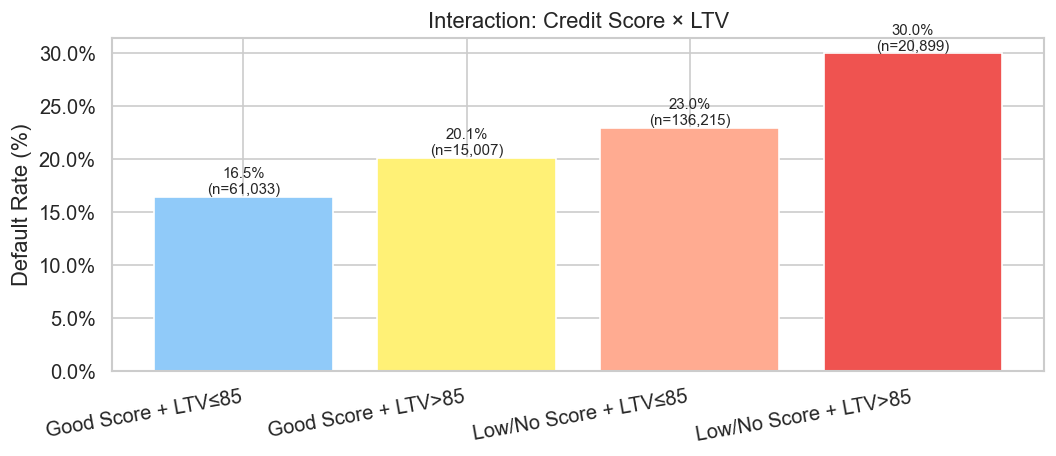

In [18]:
# Q5-C: Low CNS Score × High LTV → maximum risk segment?
df["LOW_SCORE"] = ((df["PERFORM_CNS_SCORE"] < 600) | (df["PERFORM_CNS_SCORE"] == 0)).astype(int)
risk_matrix = df.groupby(["LOW_SCORE","LTV_HIGH"])["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
risk_matrix["label"] = risk_matrix.apply(
    lambda r: f"{'Low/No Score' if r['LOW_SCORE']==1 else 'Good Score'} + LTV{'≤' if r['LTV_HIGH']==0 else '>'}85", axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#90CAF9","#FFF176","#FFAB91","#EF5350"]
bars = ax.bar(risk_matrix["label"], risk_matrix["mean"]*100, color=colors)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Interaction: Credit Score × LTV", ylabel="Default Rate (%)")
for bar, row in zip(bars, risk_matrix.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{row.mean:.1%}\n(n={row.count:,})", ha="center", fontsize=9)
plt.xticks(rotation=10, ha="right"); plt.tight_layout(); plt.show()


Default Rate by Document Count:
 DOC_COUNT  Default Rate      N
         1      0.217228 213389
         2      0.216219  19434
         3      0.165138    327
         4      0.250000      4


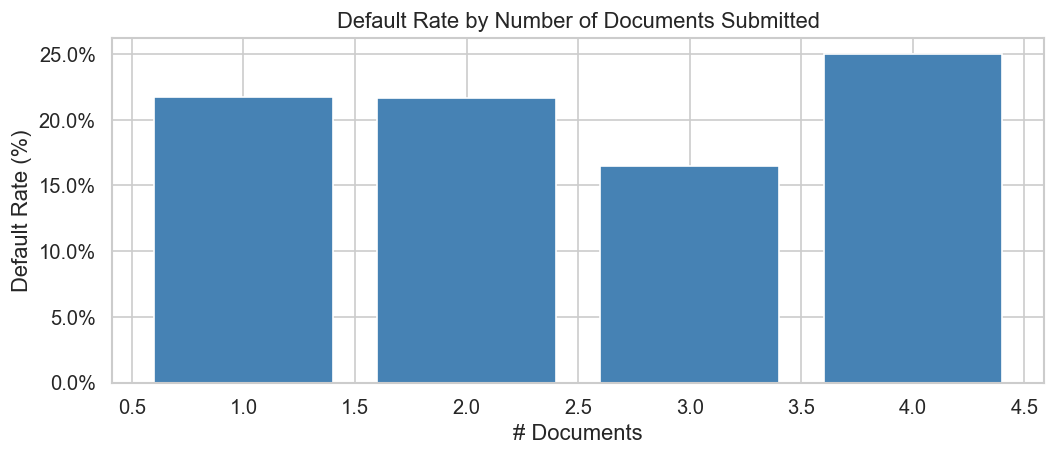

In [19]:
# Q5-D: Document completeness → risk signal?
doc_cols = ["AADHAR_FLAG","PAN_FLAG","VOTERID_FLAG","DRIVING_FLAG","PASSPORT_FLAG"]
df["DOC_COUNT"] = df[doc_cols].sum(axis=1)
doc_dr = df.groupby("DOC_COUNT")["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
print("\nDefault Rate by Document Count:")
print(doc_dr.rename(columns={"mean":"Default Rate","count":"N"}).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(doc_dr["DOC_COUNT"], doc_dr["mean"]*100, color="steelblue")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Default Rate by Number of Documents Submitted",
       xlabel="# Documents", ylabel="Default Rate (%)")
plt.tight_layout(); plt.show()

---
## 📝 Key Findings Summary

กรอกหลังรัน notebook ทั้งหมด:

| Theme | คำถาม | ผลที่ได้ | ตรงกับสมมติฐาน? | Feature candidates |
|---|---|---|---|---|
| Affordability | LTV > 85% → default สูง? | - | - | `LTV_HIGH`, `LTV_BIN` |
| Collateral | Manufacturer ID → default? | - | - | `MANUFACTURER_ID` |
| Credit Behavior | Score=0 vs Score ต่ำ | - | - | `SCORE_BAND`, `HAS_OVERDUE` |
| Temporal | Vintage year effect? | - | - | `DISBURSAL_YEAR` |
| Interaction | Low Score + High LTV = worst? | - | - | interaction features |

> **สิ่งที่ตรงข้ามกับสมมติฐาน (สำคัญที่สุด):** *กรอกที่นี่*

In [40]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 9.8 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.


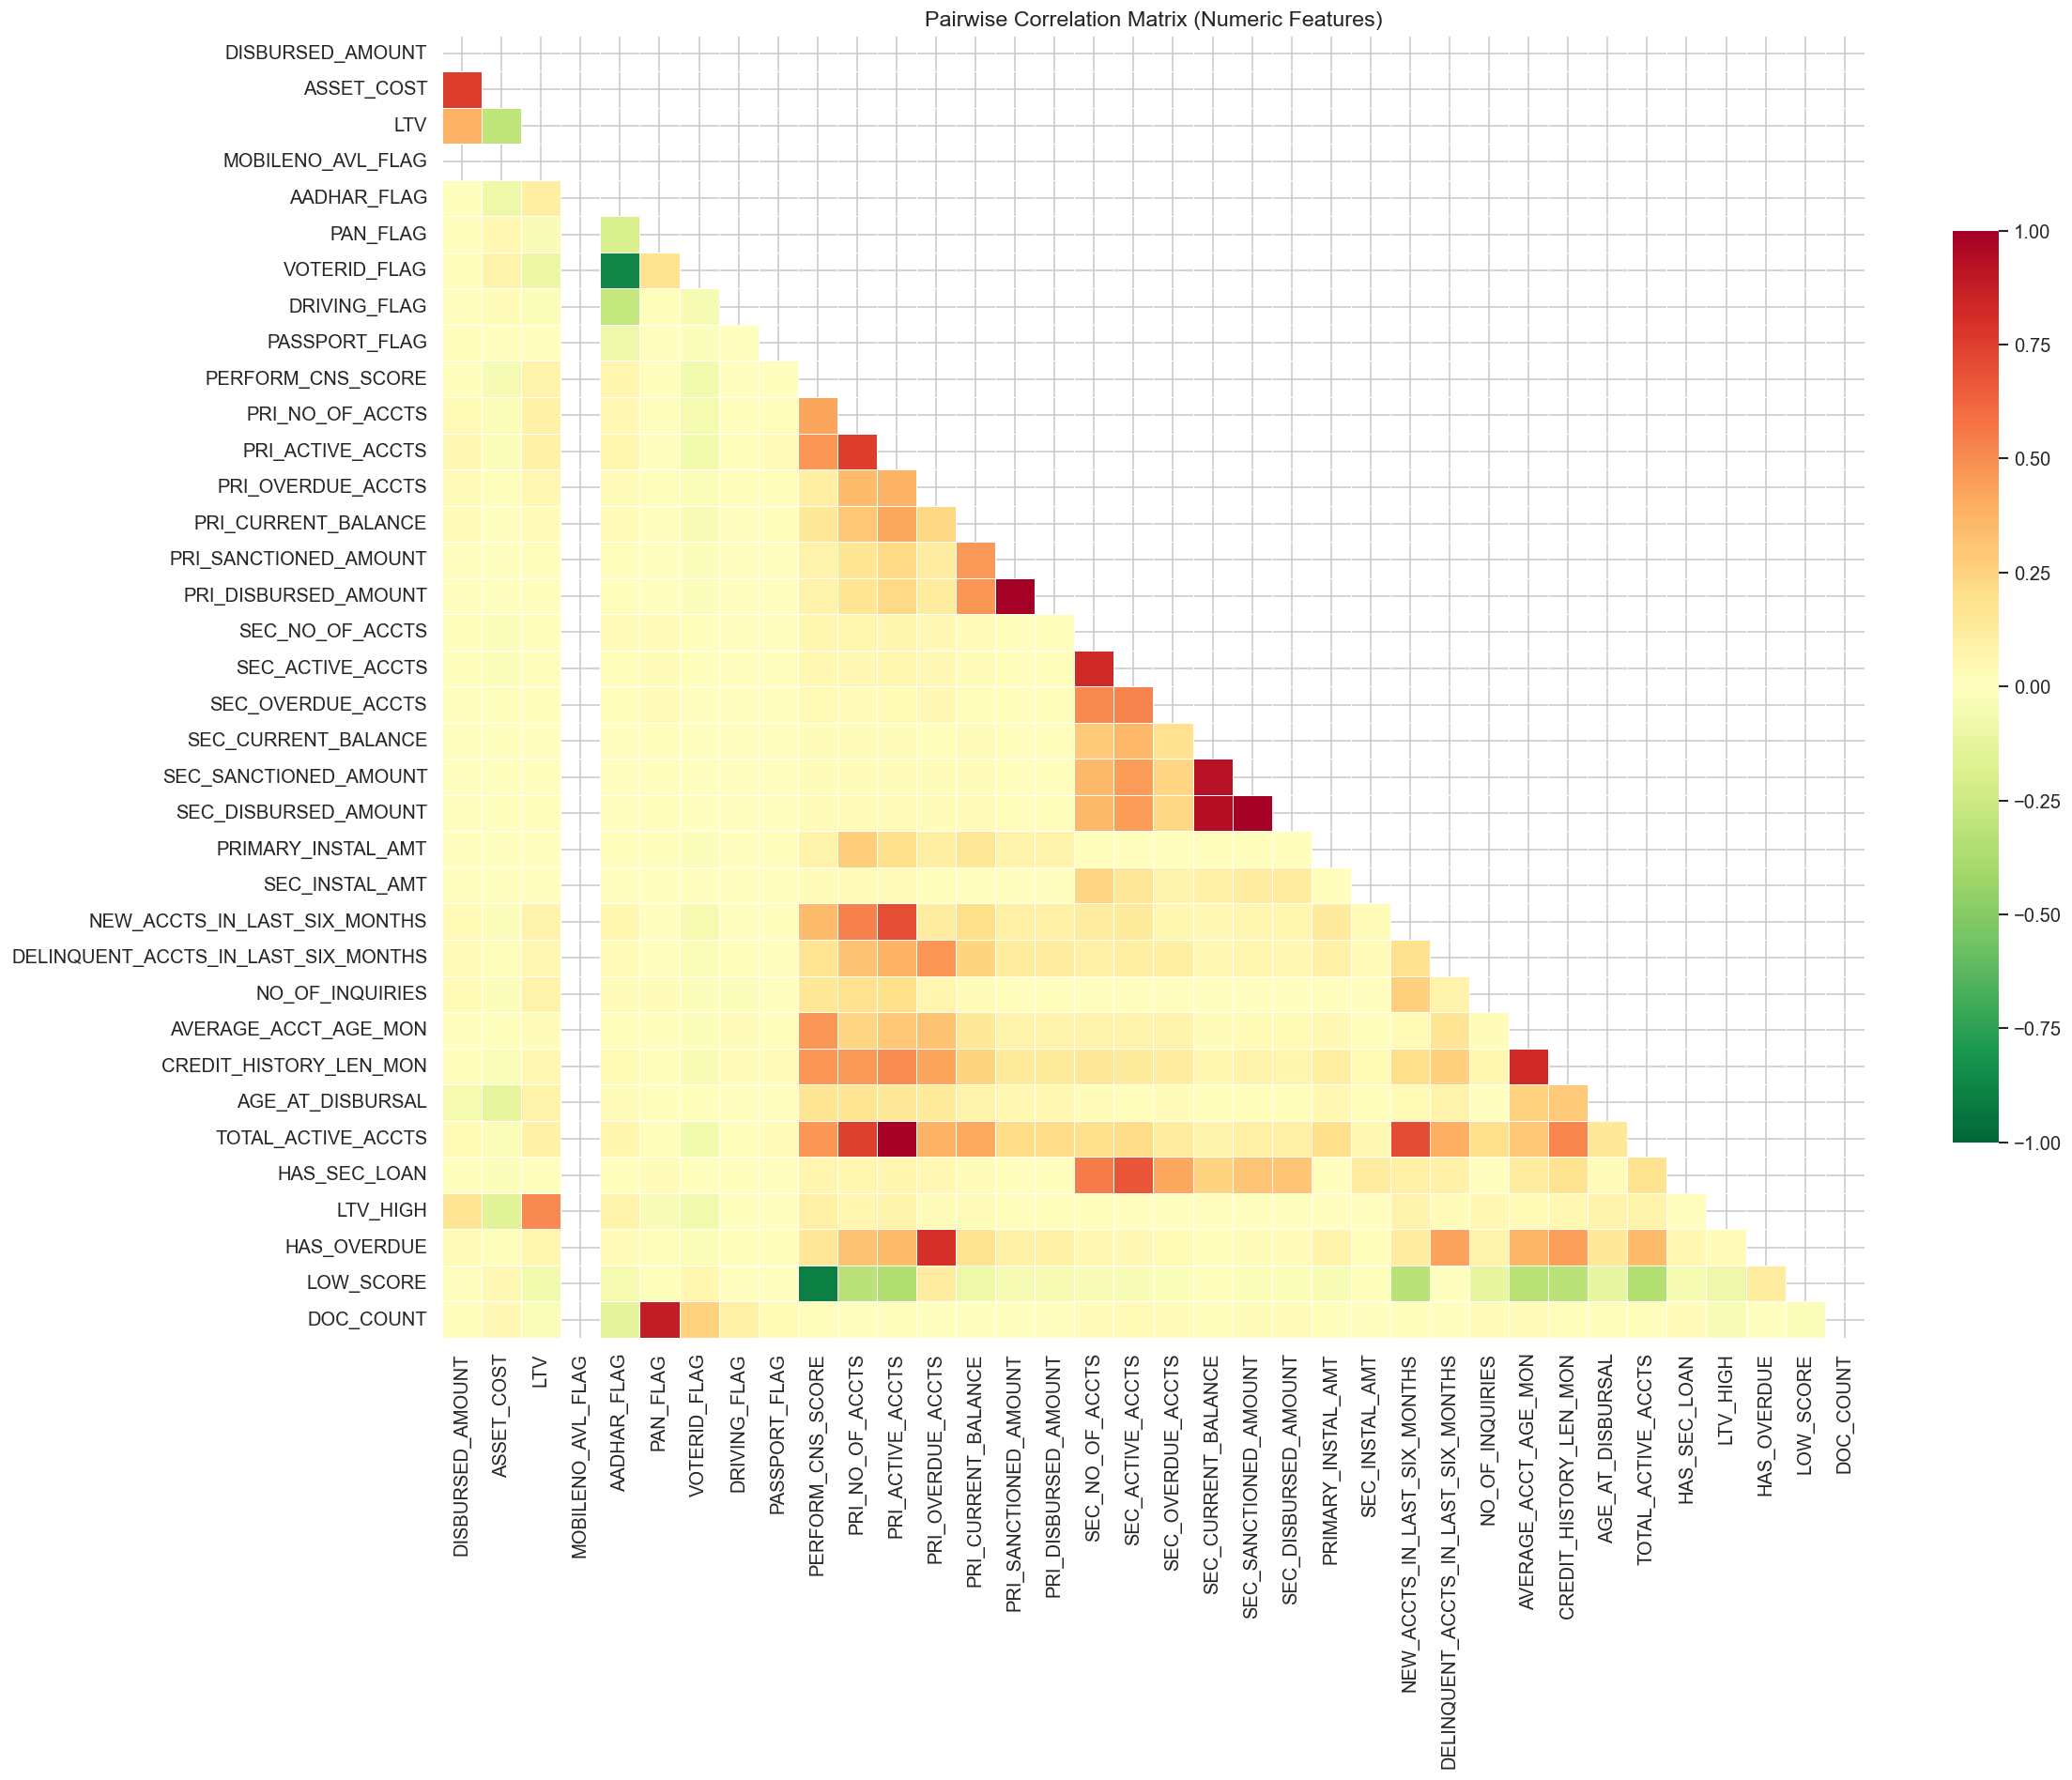

High-correlation pairs (|r| ≥ 0.7): 16 pairs

                   Feature_A                    Feature_B         r    abs_r
       SEC_SANCTIONED_AMOUNT         SEC_DISBURSED_AMOUNT  0.999646 0.999646
       PRI_SANCTIONED_AMOUNT         PRI_DISBURSED_AMOUNT  0.998747 0.998747
            PRI_ACTIVE_ACCTS           TOTAL_ACTIVE_ACCTS  0.987273 0.987273
         SEC_CURRENT_BALANCE         SEC_DISBURSED_AMOUNT  0.929995 0.929995
         SEC_CURRENT_BALANCE        SEC_SANCTIONED_AMOUNT  0.929196 0.929196
           PERFORM_CNS_SCORE                    LOW_SCORE -0.903020 0.903020
                    PAN_FLAG                    DOC_COUNT  0.877224 0.877224
                 AADHAR_FLAG                 VOTERID_FLAG -0.869259 0.869259
        AVERAGE_ACCT_AGE_MON       CREDIT_HISTORY_LEN_MON  0.831952 0.831952
             SEC_NO_OF_ACCTS             SEC_ACTIVE_ACCTS  0.828727 0.828727
           PRI_OVERDUE_ACCTS                  HAS_OVERDUE  0.800450 0.800450
             PRI_NO_OF_ACCTS  

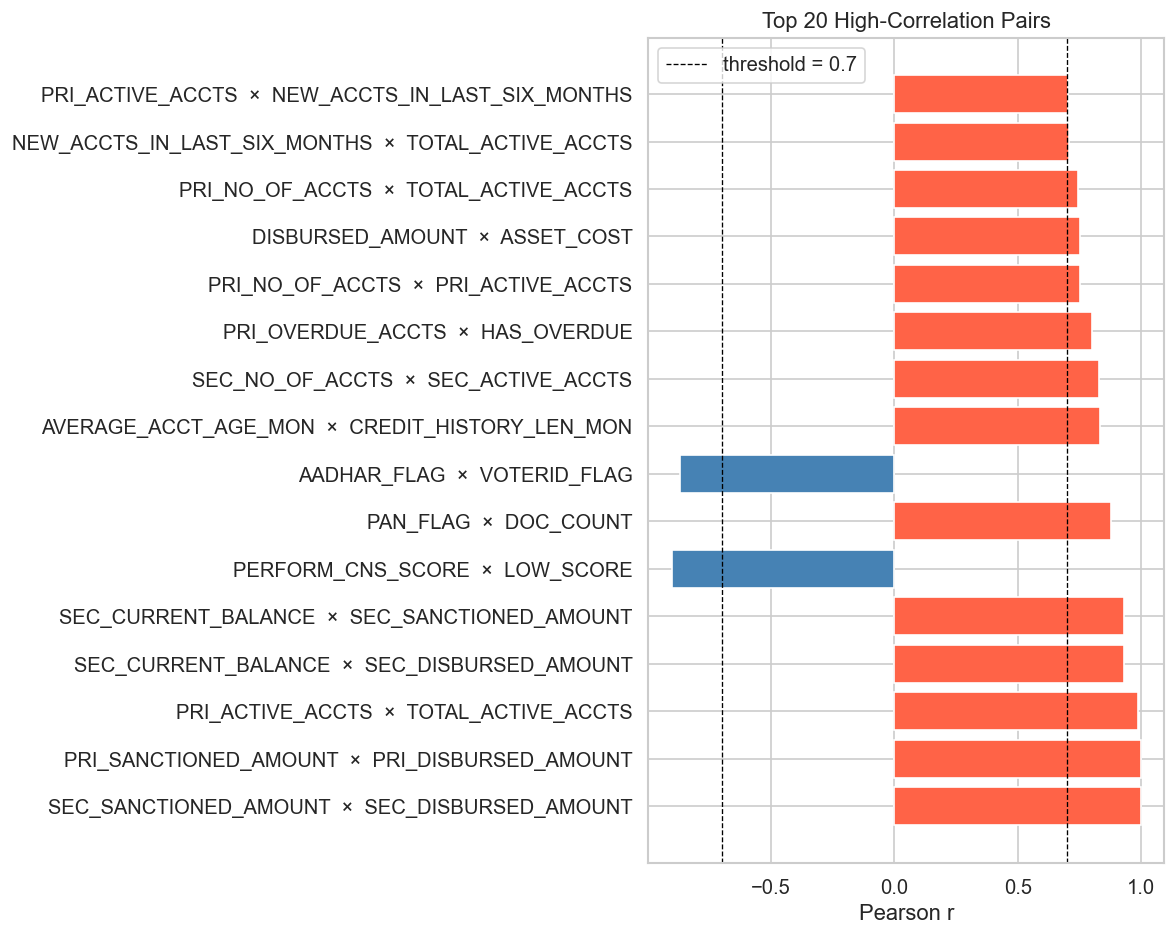

IndexError: index 36 is out of bounds for axis 1 with size 36

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# ============================================================
# MULTICOLLINEARITY CHECK — 3 ระดับ
# ============================================================

# กำหนด numeric features ที่ใช้ใน modeling (ตัด ID และ target ออก)
num_cols = df.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c not in (
    "UNIQUEID", "LOAN_DEFAULT",
    "DISBURSAL_YEAR",          # temporal — ไม่ใช่ continuous feature จริงๆ
    "BRANCH_ID", "SUPPLIER_ID", "MANUFACTURER_ID",  # categorical ที่เข้ารหัสเป็นตัวเลข
    "CURRENT_PINCODE_ID", "STATE_ID", "EMPLOYEE_CODE_ID",
)]

df_num = df[num_cols].dropna()

# ============================================================
# LEVEL 1 — Correlation Heatmap (มองภาพรวม)
# ============================================================
corr = df_num.corr()

# mask แค่ triangle ล่างเพื่อไม่ให้ซ้ำ
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr, mask=mask, annot=False, fmt=".2f",
    cmap="RdYlGn_r", center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.7}
)
ax.set_title("Pairwise Correlation Matrix (Numeric Features)", fontsize=14)
plt.tight_layout(); plt.show()

# ============================================================
# LEVEL 2 — High Correlation Pairs (|r| > 0.7)
# หลักการ: r > 0.7 ถือว่า "สูงมาก" และมักจะเป็น redundant
# ============================================================
threshold = 0.7

# แปลง corr matrix เป็น long format แล้ว filter
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_A", "level_1": "Feature_B", 0: "r"})
    .assign(abs_r=lambda x: x["r"].abs())
    .query("abs_r >= @threshold")
    .sort_values("abs_r", ascending=False)
)

print(f"High-correlation pairs (|r| ≥ {threshold}): {len(high_corr)} pairs\n")
print(high_corr.to_string(index=False))

# plot top 20 pairs เพื่อให้เห็นง่าย
top20 = high_corr.head(20).copy()
top20["pair"] = top20["Feature_A"] + "  ×  " + top20["Feature_B"]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["tomato" if r > 0 else "steelblue" for r in top20["r"]]
ax.barh(top20["pair"], top20["r"], color=colors)
ax.axvline(threshold, color="black", linestyle="--", linewidth=0.8, label=f"threshold = {threshold}")
ax.axvline(-threshold, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Top 20 High-Correlation Pairs")
ax.set_xlabel("Pearson r")
ax.legend()
plt.tight_layout(); plt.show()

# ============================================================
# LEVEL 3 — VIF (Variance Inflation Factor)
# VIF วัดว่า feature X หนึ่งตัวถูก "อธิบาย" โดย features อื่นได้แค่ไหน
# VIF = 1/(1 - R²) ของการ regress X กับ features ที่เหลือ
# Rule of thumb: VIF > 10 = ปัญหา, VIF > 5 = ควรระวัง
# ============================================================

# drop rows ที่มี NaN ก่อนคำนวณ VIF
X_vif = df_num.copy()

# VIF ต้องการ constant term
X_const = add_constant(X_vif)

vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_const.values, i + 1)  # +1 เพราะ index 0 คือ constant
        for i in range(len(X_vif.columns))
    ]
}).sort_values("VIF", ascending=False)

print("\nVIF Results:")
print(vif_data.to_string(index=False))

# color-code ตาม severity
def vif_color(v):
    if v > 10: return "tomato"
    elif v > 5: return "orange"
    else: return "steelblue"

colors_vif = [vif_color(v) for v in vif_data["VIF"]]

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(vif_data["Feature"], vif_data["VIF"], color=colors_vif)
ax.axvline(10, color="red", linestyle="--", linewidth=1, label="VIF = 10 (High)")
ax.axvline(5, color="orange", linestyle="--", linewidth=1, label="VIF = 5 (Moderate)")
ax.set_title("Variance Inflation Factor (VIF) per Feature")
ax.set_xlabel("VIF")
ax.legend()
plt.tight_layout(); plt.show()

# ============================================================
# LEVEL 4 — Hierarchical Clustering of Features
# ใช้ distance = 1 - |r| เพื่อจัดกลุ่ม features ที่คล้ายกัน
# ช่วยตัดสินใจว่าควรเก็บ "ตัวแทน" จากแต่ละ cluster ไว้ตัวเดียว
# ============================================================

# แปลง correlation เป็น distance
dist_matrix = 1 - corr.abs()
# แก้ floating point ที่อาจทำให้ค่าติดลบนิดหน่อย
dist_matrix = dist_matrix.clip(lower=0)
condensed = squareform(dist_matrix, checks=False)

linkage = hierarchy.ward(condensed)

fig, ax = plt.subplots(figsize=(18, 8))
hierarchy.dendrogram(
    linkage,
    labels=corr.columns.tolist(),
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.5,   # ตัดที่ distance = 0.5 หมายความว่า |r| ≥ 0.5 ใน cluster เดียวกัน
    ax=ax
)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="cut threshold = 0.5")
ax.set_title("Hierarchical Clustering of Features (Ward linkage, distance = 1 - |r|)")
ax.set_ylabel("Distance")
ax.legend()
plt.tight_layout(); plt.show()

# ============================================================
# สรุป: Features ที่ควร Drop หรือ Merge
# ============================================================
print("\n=== RECOMMENDATION ===")
print("Features ที่มี VIF > 10 (ควร drop หรือ aggregate):")
print(vif_data[vif_data["VIF"] > 10]["Feature"].tolist())

print("\nFeatures ที่มี VIF 5–10 (ควรระวัง):")
print(vif_data[(vif_data["VIF"] > 5) & (vif_data["VIF"] <= 10)]["Feature"].tolist())

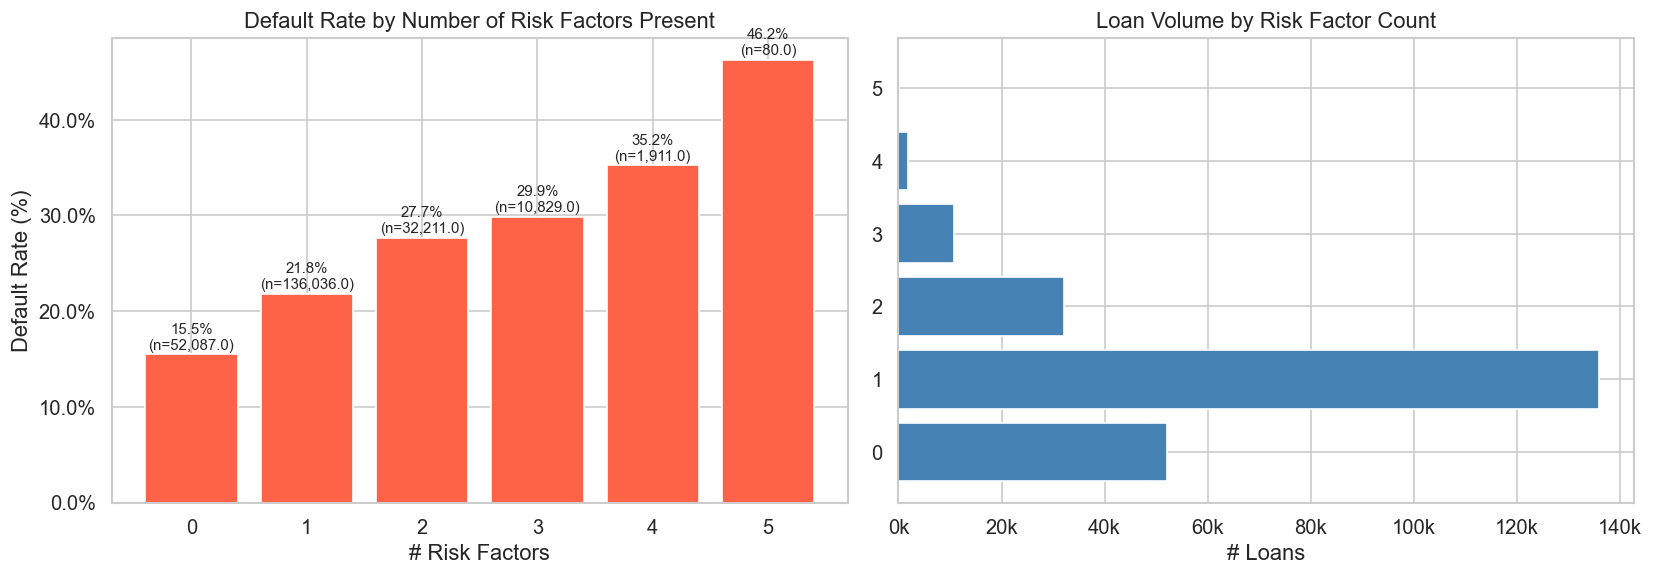

 RISK_SCORE_COUNT  default_rate      n
                0      0.154991  52087
                1      0.218229 136036
                2      0.276551  32211
                3      0.298550  10829
                4      0.352172   1911
                5      0.462500     80


In [42]:
# ============================================================
# EXTRA EDA 1 — Risk Factor Stacking
# คำถาม: ลูกค้าที่มีหลาย risk factors พร้อมกัน default มากแค่ไหน?
# ============================================================

df["RISK_SCORE_COUNT"] = (
    (df["LTV"] > 85).astype(int) +
    (df["HAS_OVERDUE"] == 1).astype(int) +
    (df["LOW_SCORE"] == 1).astype(int) +
    (df["DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS"] > 0).astype(int) +
    (df["NO_OF_INQUIRIES"] >= 3).astype(int)
)

risk_stack = (
    df.groupby("RISK_SCORE_COUNT")["LOAN_DEFAULT"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "default_rate", "count": "n"})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# default rate by risk count
axes[0].bar(
    risk_stack["RISK_SCORE_COUNT"].astype(str),
    risk_stack["default_rate"] * 100,
    color="tomato"
)
for _, row in risk_stack.iterrows():
    axes[0].text(row["RISK_SCORE_COUNT"], row["default_rate"]*100 + 0.5,
                 f"{row['default_rate']:.1%}\n(n={row['n']:,})", ha="center", fontsize=9)
axes[0].set_title("Default Rate by Number of Risk Factors Present")
axes[0].set_xlabel("# Risk Factors")
axes[0].set_ylabel("Default Rate (%)")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# volume pyramid
axes[1].barh(
    risk_stack["RISK_SCORE_COUNT"].astype(str),
    risk_stack["n"],
    color="steelblue"
)
axes[1].set_title("Loan Volume by Risk Factor Count")
axes[1].set_xlabel("# Loans")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.tight_layout(); plt.show()
print(risk_stack.to_string(index=False))

In [44]:
# ตัวอย่างสำหรับ NO_OF_INQUIRIES
inq_dr = (df.groupby("NO_OF_INQUIRIES")["LOAN_DEFAULT"]
            .agg(["mean", "count"])
            .reset_index()
            .query("count >= 100"))  # กรองเฉพาะที่มี sample พอ
inq_dr

,NO_OF_INQUIRIES,mean,count
0,0,0.210719,201961
1,1,0.244155,22285
2,2,0.275652,5409
3,3,0.292586,1767
4,4,0.307895,760
5,5,0.381924,343
6,6,0.380753,239
7,7,0.407407,135
8,8,0.419048,105


In [46]:
score_dr = (df.groupby("PERFORM_CNS_SCORE")
              .agg(default_rate=("LOAN_DEFAULT", "mean"), n=("LOAN_DEFAULT", "count"))
              .reset_index()
              .query("n >= 50"))
score_dr

,PERFORM_CNS_SCORE,default_rate,n
0,0,0.231313,116950
2,14,0.213115,976
3,15,0.255777,3765
4,16,0.183709,2885
5,17,0.209695,3672
...,...,...,...
543,836,0.154126,1927
546,839,0.101695,118
551,844,0.063492,63
552,845,0.095785,522


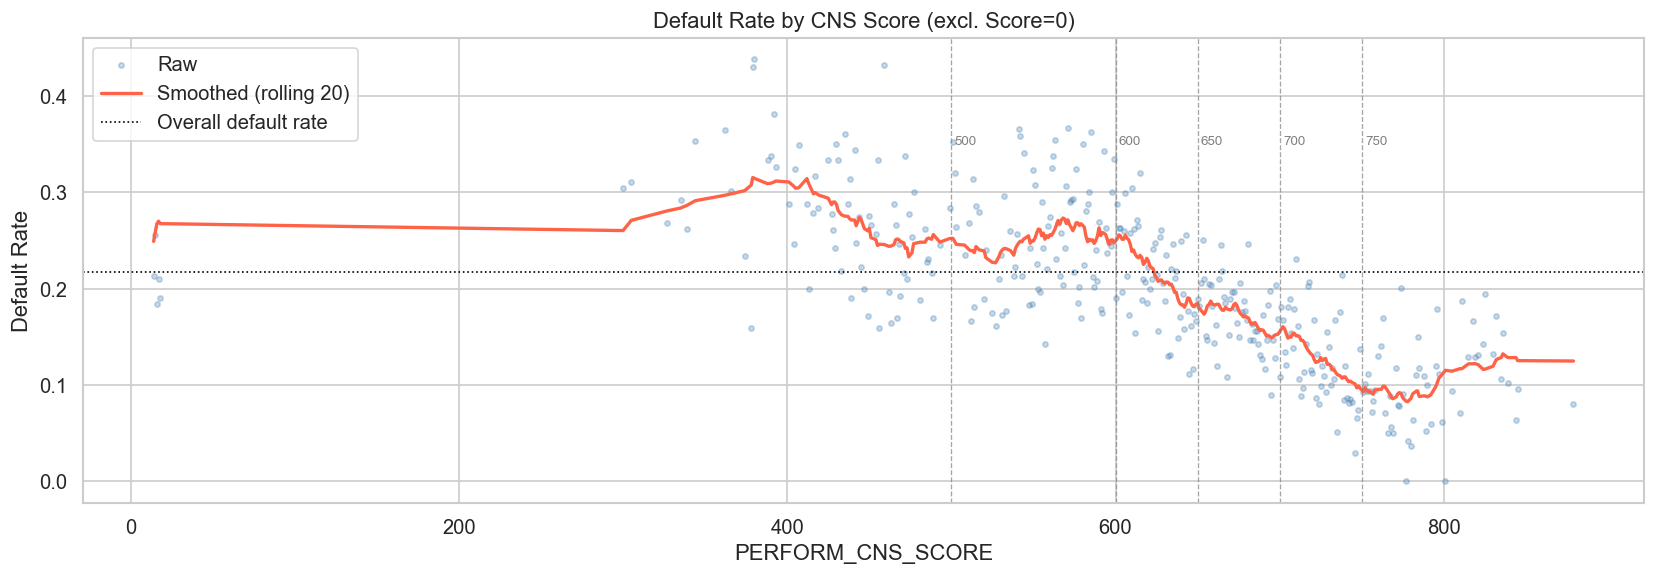

In [47]:
# smoothing ก่อนเพื่อหา natural break
# กรองเฉพาะ score > 0 และมี sample พอ
score_clean = score_dr[score_dr["PERFORM_CNS_SCORE"] > 0].copy()

# rolling average เพื่อลด noise
score_clean["dr_smooth"] = (
    score_clean.set_index("PERFORM_CNS_SCORE")["default_rate"]
    .rolling(window=20, center=True, min_periods=5)
    .mean()
    .values
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(score_clean["PERFORM_CNS_SCORE"], score_clean["default_rate"],
           alpha=0.3, s=10, color="steelblue", label="Raw")
ax.plot(score_clean["PERFORM_CNS_SCORE"], score_clean["dr_smooth"],
        color="tomato", linewidth=2, label="Smoothed (rolling 20)")

# ลาก reference lines ที่ candidate thresholds
for cutoff in [500, 600, 650, 700, 750]:
    ax.axvline(cutoff, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.text(cutoff + 2, 0.35, str(cutoff), fontsize=8, color="gray")

ax.axhline(0.2171, color="black", linestyle=":", linewidth=1, label="Overall default rate")
ax.set_title("Default Rate by CNS Score (excl. Score=0)")
ax.set_xlabel("PERFORM_CNS_SCORE")
ax.set_ylabel("Default Rate")
ax.legend()
plt.tight_layout(); plt.show()

SCORE_TIER
No Score                116950
Super-Prime (700+)       51577
Subprime (<600)          40327
Prime (650–700)          13457
Near-Prime (600–650)     10843
Name: count, dtype: int64
SCORE_BAND
<500       30023
700-750    25895
800+       14373
650-700    13457
750-800    11309
600-650    10843
500-600    10304
No Hist        0
Name: count, dtype: int64


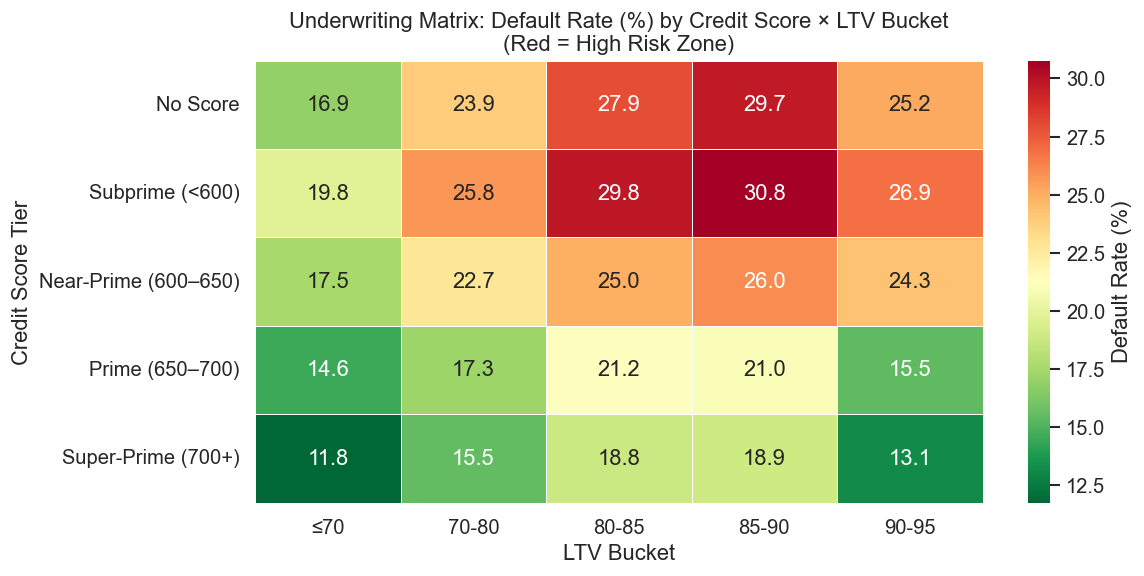

<Figure size 768x576 with 0 Axes>

In [54]:
# ============================================================
# EXTRA EDA 2 — Underwriting Matrix: LTV Bucket × Credit Score Band
# คำถาม: combination ไหนที่ควร reject หรือ price up?
# ============================================================

def score_tier(s):
    # Score = 0 คือ "No Bureau History" ไม่ใช่ low score
    # ต้องแยกออกมาเพราะเป็นคนละ population
    if pd.isna(s) or s == "No Bureau History Available":
        return "No Score"
    
    # <500: มีประวัติแต่แย่มาก — default rate สูงสุดในกลุ่มที่มี score
    # Data: smoothed curve อยู่แถว 26-31% ตลอดช่วงนี้
    if s in ["<500", "500-600"]:  
        return "Subprime (<600)"
    
    # 600-650: ยังอยู่เหนือ overall default rate
    # 650 คือจุดที่ curve ตัด overall rate line — data-driven cutoff
    if s in ["600-650"]:
        return "Near-Prime (600–650)"
    
    # 650-700: ต่ำกว่า overall rate แล้ว แต่ยังไม่ stable
    if s in ["650-700"]:
        return "Prime (650–700)"
    
    # 700+: curve flatten ที่ ~10-15% — low risk zone ที่ชัดเจน
    return "Super-Prime (700+)"
df["SCORE_TIER"] = df["SCORE_BAND"].apply(score_tier)

# ตรวจสอบก่อนว่า SCORE_TIER มีค่าอะไรบ้าง
print(df["SCORE_TIER"].value_counts())

# ถ้า SCORE_TIER ยังไม่มี ให้ apply ใหม่โดยใช้ SCORE_BAND
# ซึ่งต้องแน่ใจว่า SCORE_BAND มีค่าตรงกับที่ map ไว้
print(df["SCORE_BAND"].value_counts().head(10))

# pivot table เหมือนเดิม
matrix = (
    df.groupby(["SCORE_TIER", "LTV_BIN"])["LOAN_DEFAULT"]
    .mean()
    .unstack()
    # แก้ reindex ให้ตรงกับชื่อ tier ที่ใช้จริง — เรียงจากเสี่ยงสูงไปต่ำ
    .reindex([
        "No Score",
        "Subprime (<600)",
        "Near-Prime (600–650)",
        "Prime (650–700)",
        "Super-Prime (700+)"
    ])
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    matrix * 100,
    annot=True, fmt=".1f", cmap="RdYlGn_r",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Default Rate (%)"}
)
ax.set_title(
    "Underwriting Matrix: Default Rate (%) by Credit Score × LTV Bucket\n"
    "(Red = High Risk Zone)"
)
ax.set_xlabel("LTV Bucket")
ax.set_ylabel("Credit Score Tier")
plt.tight_layout(); plt.show()
ax.set_title("Underwriting Matrix: Default Rate (%) by Credit Score × LTV Bucket\n(Red = High Risk Zone)")
ax.set_xlabel("LTV Bucket")
ax.set_ylabel("Credit Score Tier")
plt.tight_layout(); plt.show()

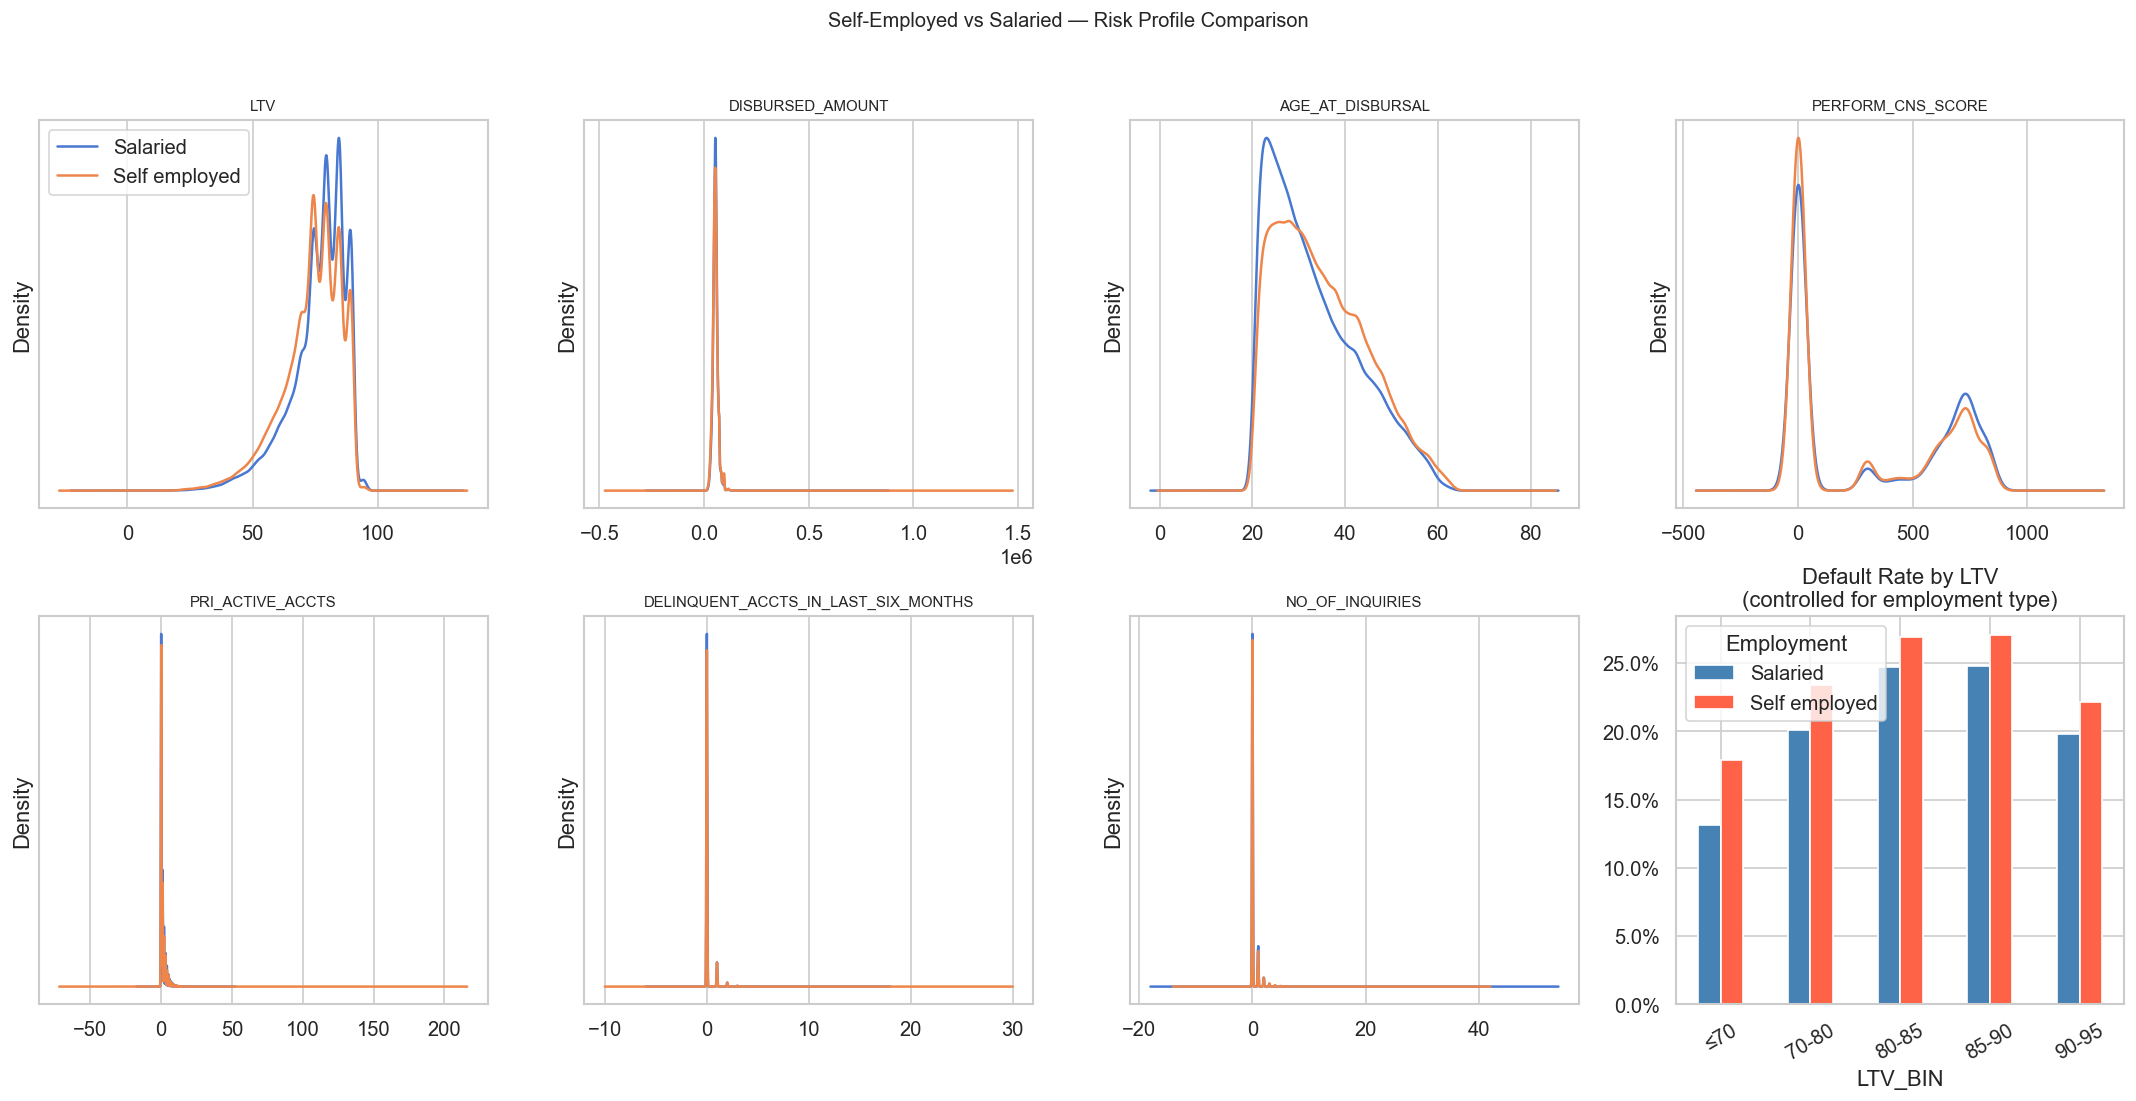

In [49]:
# ============================================================
# EXTRA EDA 3 — Employment Type Deep Dive
# คำถาม: self-employed default สูงกว่าเพราะ profile ต่างกัน
#         หรือเพราะ employment type เองเป็น independent risk factor?
# ============================================================

emp = df[df["EMPLOYMENT_TYPE"].notna()].copy()

# เปรียบเทียบ profile ระหว่าง salaried vs self-employed
profile_cols = ["LTV", "DISBURSED_AMOUNT", "AGE_AT_DISBURSAL",
                "PERFORM_CNS_SCORE", "PRI_ACTIVE_ACCTS",
                "DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS", "NO_OF_INQUIRIES"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(profile_cols):
    emp.groupby("EMPLOYMENT_TYPE")[col].plot(
        kind="kde", ax=axes[i], legend=(i == 0)
    )
    axes[i].set_title(col, fontsize=9)
    axes[i].set_yticks([])

# default rate controlled for LTV (same LTV bucket — still different?)
ctrl = (
    emp.groupby(["EMPLOYMENT_TYPE", "LTV_BIN"])["LOAN_DEFAULT"]
    .mean().unstack()
)
ctrl.T.plot(kind="bar", ax=axes[-1], color=["steelblue", "tomato"])
axes[-1].set_title("Default Rate by LTV\n(controlled for employment type)")
axes[-1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[-1].legend(title="Employment")
axes[-1].tick_params(axis="x", rotation=30)

plt.suptitle("Self-Employed vs Salaried — Risk Profile Comparison", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

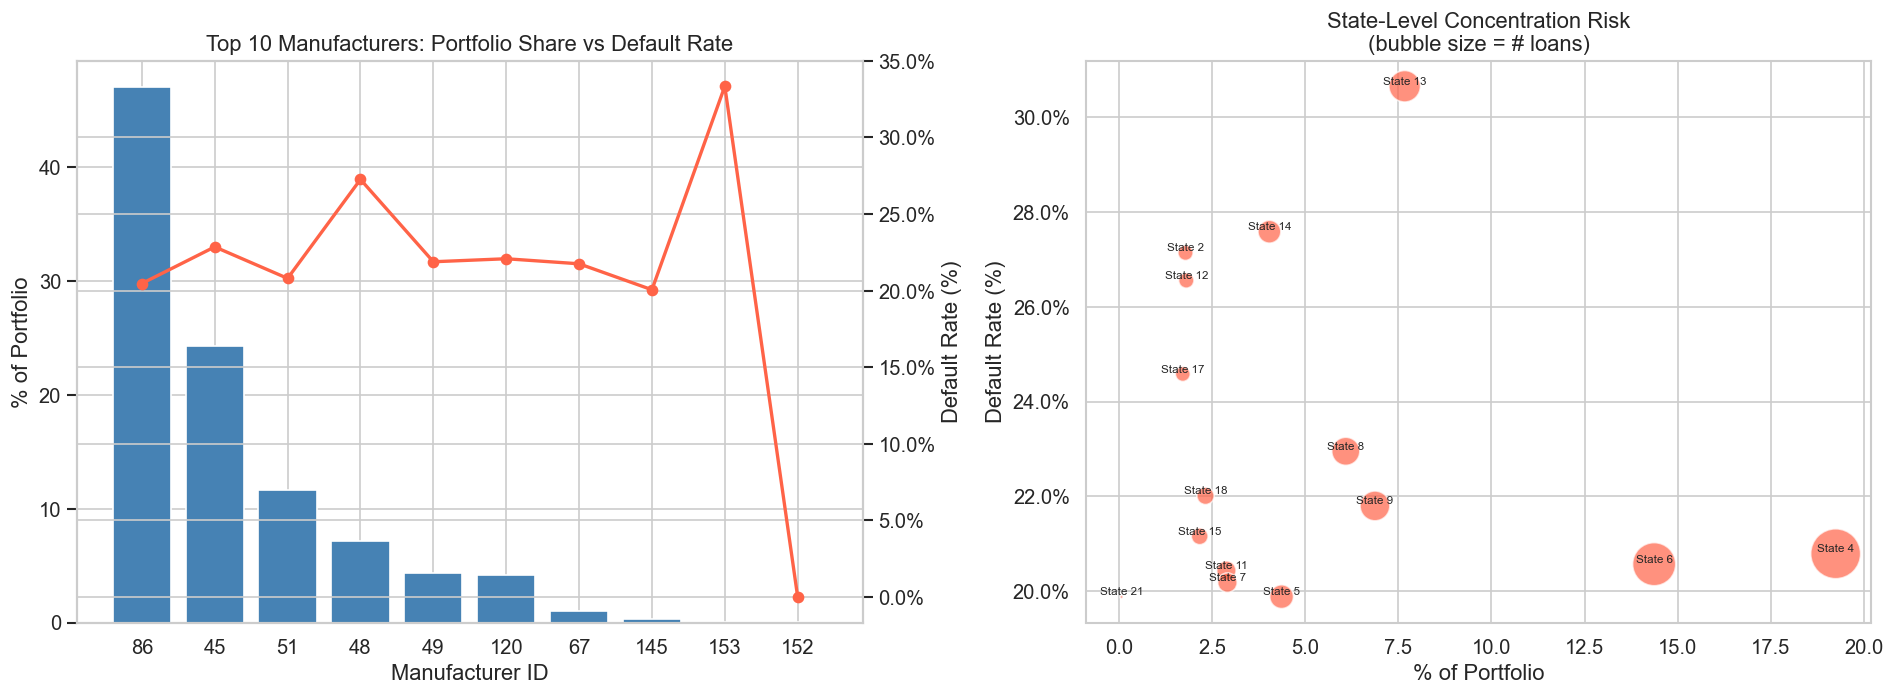

In [50]:
# ============================================================
# EXTRA EDA 4 — Concentration Risk
# คำถาม: portfolio กระจุกอยู่ที่ manufacturer / branch ไหน?
#         ถ้า segment นั้น default พร้อมกัน portfolio เสียหายแค่ไหน?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Manufacturer concentration — top 10
mfr = (
    df.groupby("MANUFACTURER_ID")
    .agg(
        loan_count=("LOAN_DEFAULT", "count"),
        default_rate=("LOAN_DEFAULT", "mean"),
        total_disbursed=("DISBURSED_AMOUNT", "sum")
    )
    .sort_values("loan_count", ascending=False)
    .head(10)
    .reset_index()
)
mfr["pct_of_portfolio"] = mfr["loan_count"] / len(df) * 100

ax = axes[0]
bars = ax.bar(mfr["MANUFACTURER_ID"].astype(str), mfr["pct_of_portfolio"], color="steelblue")
ax2 = ax.twinx()
ax2.plot(range(len(mfr)), mfr["default_rate"]*100, "o-", color="tomato", linewidth=2)
ax.set_title("Top 10 Manufacturers: Portfolio Share vs Default Rate")
ax.set_xlabel("Manufacturer ID")
ax.set_ylabel("% of Portfolio")
ax2.set_ylabel("Default Rate (%)")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

# State concentration
state = (
    df.groupby("STATE_ID")
    .agg(loan_count=("LOAN_DEFAULT", "count"), default_rate=("LOAN_DEFAULT", "mean"))
    .sort_values("default_rate", ascending=False)
    .head(15)
    .reset_index()
)
state["pct"] = state["loan_count"] / len(df) * 100

axes[1].scatter(state["pct"], state["default_rate"]*100,
                s=state["loan_count"]/50, color="tomato", alpha=0.7, edgecolors="white")
for _, row in state.iterrows():
    axes[1].annotate(f"State {int(row['STATE_ID'])}",
                     (row["pct"], row["default_rate"]*100),
                     fontsize=7, ha="center", va="bottom")
axes[1].set_title("State-Level Concentration Risk\n(bubble size = # loans)")
axes[1].set_xlabel("% of Portfolio")
axes[1].set_ylabel("Default Rate (%)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout(); plt.show()